In [3]:
"""
Plot_Portfolio_Standalone.py
============================
Standalone deployment-map plotter for a single portfolio .npz file.
Draws coastline, state borders, and bathymetry contours — no Run folder,
summary.csv, or run_manifest.json required.

Usage:
    1. Set the paths in the CONFIGURATION block below.
    2. Run:  python Plot_Portfolio_Standalone.py
"""

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xarray as xr
from matplotlib.lines import Line2D
from pathlib import Path

# ======================================================================
# CONFIGURATION — edit these paths for your machine / run
# ======================================================================

# Portfolio shard to plot
PORTFOLIO_NPZ = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\GenPU_ATB_18MW_2030_Florida_Florida_HalfScale_63.62_KitePower_Design3_Florida_100m_Transmission_1200MW_Florida\LCOE_120\Portfolio_LCOE_120.npz"

# Geospatial overlays
DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"

# Collection radius in km  (set manually since there's no run_manifest.json)
MAX_COLLECTION_RADIUS_KM = 30.0

# Output — set to a folder path to save a PNG, or None to just display
SAVE_DIR  = None        # e.g. r"C:\Users\rmiller9\Documents\East Coast Model\Plots"
SAVE_NAME = "Plot_DeploymentMap_Geo.png"

# Axis padding (degrees) around deployed sites
PAD = 2.0

# ======================================================================
# STYLE
# ======================================================================

TECH_COLORS = {
    "Wind":    "dodgerblue",
    "Kites":   "limegreen",
    "WECs":    "darkorange",
    "Coaxial": "mediumorchid",
    "Tidal":   "crimson",
}

DEPTH_LEVELS = [30, 100, 500, 1000, 2000]
DEPTH_COLORS = {
    30:   "purple",
    100:  "royalblue",
    500:  "teal",
    1000: "darkorange",
    2000: "gold",
}

# ======================================================================
# HELPERS
# ======================================================================

def km_to_deg_lon(km, lat_deg):
    return km / (111.32 * np.cos(np.radians(lat_deg)))

def km_to_deg_lat(km):
    return km / 110.574

# ======================================================================
# LOAD GEO DATA
# ======================================================================

print("Loading geospatial overlays …")

ds      = xr.open_dataset(DEPTH_NC)
lat_d   = ds["lat"].values[::2]
lon_d   = ds["lon"].values[::2]
depth   = ds["depth"].values[::2, ::2]
LonGrid, LatGrid = np.meshgrid(lon_d, lat_d)
ds.close()

coast   = gpd.read_file(COAST_SHP)
borders = gpd.read_file(BORDERS_SHP)
coast   = coast.set_crs(epsg=4326)   if coast.crs is None   else coast.to_crs(epsg=4326)
borders = borders.set_crs(epsg=4326) if borders.crs is None else borders.to_crs(epsg=4326)

# ======================================================================
# LOAD PORTFOLIO
# ======================================================================

print(f"Loading portfolio: {PORTFOLIO_NPZ}")
Z = np.load(PORTFOLIO_NPZ, allow_pickle=True)

lcoe_target   = float(Z["LCOE_Target"])
lcoe_achieved = float(Z["LCOE_Achieved"])
deployments   = Z["Deployments_ByTech"].item()      # {tech: {latlong, units, …}}
s_arr         = Z["s"]

# --- Transmission hub location ---
# Pull the transmission design path stored inside the portfolio file,
# then load just the hub lat/long table from that file.
PathTransmissionDesign = str(Z["PathTransmissionDesign"])
Z.close()

TData        = np.load(PathTransmissionDesign, allow_pickle=True)["TransmissionLineParameters"].item()
TransLatLong = TData["TL_LatLong"]
print(f"Transmission design: {PathTransmissionDesign}")
print(f"  {TransLatLong.shape[0]} candidate hubs")

# ======================================================================
# PLOT
# ======================================================================

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor("aliceblue")

legend_handles = []
all_lons = []
all_lats = []
total_units = 0

# --- Deployed sites per technology ---
for tech, dep in deployments.items():
    ll    = np.asarray(dep["latlong"])       # (n_active, 2)  → [lat, lon]
    units = np.asarray(dep["units"], dtype=float)

    if len(units) == 0:
        continue

    color = TECH_COLORS.get(tech, "gray")
    sizes = 15 + units * 8

    ax.scatter(ll[:, 1], ll[:, 0], s=sizes, c=color,
               edgecolors="black", linewidths=0.3, alpha=0.85, zorder=4)

    n_sites = len(units)
    n_units = int(units.sum())
    total_units += n_units
    legend_handles.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
               markeredgecolor="black", markersize=8,
               label=f"{tech}: {n_sites} sites, {n_units} units")
    )

    all_lons.extend(ll[:, 1].tolist())
    all_lats.extend(ll[:, 0].tolist())

# --- Transmission hub ---
hub_idx = np.argmax(s_arr)
hub_ll  = TransLatLong[hub_idx]

ax.scatter(hub_ll[1], hub_ll[0], s=250, c="red", marker="*",
           edgecolors="black", linewidths=0.8, zorder=6)
legend_handles.append(
    Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
           markeredgecolor="black", markersize=14, label="Transmission Hub")
)
all_lons.append(hub_ll[1])
all_lats.append(hub_ll[0])

# --- Collection radius circle ---
r_lat = km_to_deg_lat(MAX_COLLECTION_RADIUS_KM)
r_lon = km_to_deg_lon(MAX_COLLECTION_RADIUS_KM, hub_ll[0])
circle = mpatches.Ellipse(
    (hub_ll[1], hub_ll[0]), width=2 * r_lon, height=2 * r_lat,
    fill=False, edgecolor="red", linewidth=1.5, linestyle="--", zorder=5,
)
ax.add_patch(circle)
legend_handles.append(
    Line2D([0], [0], color="red", linestyle="--", lw=1.5,
           label=f"Collection radius ({MAX_COLLECTION_RADIUS_KM:.0f} km)")
)

# --- Domain bounds ---
xlim = (min(all_lons) - PAD, max(all_lons) + PAD)
ylim = (min(all_lats) - PAD, max(all_lats) + PAD)

# --- Geospatial overlays (depth contours + coastline + borders) ---
for lvl in DEPTH_LEVELS:
    cs = ax.contour(LonGrid, LatGrid, depth,
                    levels=[lvl], colors=[DEPTH_COLORS[lvl]],
                    linewidths=1.0, zorder=3)
    ax.clabel(cs, inline=True, fontsize=7, fmt={lvl: f"{lvl} m"})

coast.plot(ax=ax, linewidth=1.2, color="black", zorder=5, antialiased=False)
borders.plot(ax=ax, linewidth=0.6, color="black", zorder=5, antialiased=False)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# --- Legends ---
depth_handles = [
    Line2D([0], [0], color=DEPTH_COLORS[l], lw=2, label=f"{l} m")
    for l in DEPTH_LEVELS
]

leg1 = ax.legend(handles=legend_handles, loc="upper left",
                 frameon=True, framealpha=0.9, facecolor="white",
                 title="Deployments")
ax.add_artist(leg1)

ax.legend(handles=depth_handles, loc="lower right",
          frameon=True, framealpha=0.9, facecolor="white",
          title="Bathymetry")

ax.set_title(
    f"Portfolio Deployment — LCOE Target: {lcoe_target:.0f} $/MWh"
    f"  |  Achieved: {lcoe_achieved:.1f} $/MWh"
    f"  |  {total_units} total units",
    fontsize=11,
)

plt.tight_layout()

# --- Save / show ---
if SAVE_DIR:
    import os
    out = os.path.join(SAVE_DIR, SAVE_NAME)
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved → {out}")

plt.show()
print("Done.")

Loading geospatial overlays …
Loading portfolio: C:\Users\rmiller9\Documents\East Coast Model\Portfolios\GenPU_ATB_18MW_2030_Florida_Florida_HalfScale_63.62_KitePower_Design3_Florida_100m_Transmission_1200MW_Florida\LCOE_120\Portfolio_LCOE_120.npz


KeyError: 'Deployments_ByTech is not a file in the archive'

In [4]:
Z = np.load(PORTFOLIO_NPZ, allow_pickle=True)
print(list(Z.keys()))
Z.close()

['LCOE_Target', 'LCOE_Achieved', 'Total_MW_Avg', 'Wind_MW_Avg', 'Wave_MW_Avg', 'Kite_MW_Avg', 'Curtailment_MW_Avg', 'Cost_Wind_MperYear', 'Cost_Wave_MperYear', 'Cost_Kite_MperYear', 'Cost_Transmission_MperYear', 'Total_Cost_MperYear', 'Y_Wind', 'Y_Wave', 'Y_Kite', 'W_Wind', 'W_Wave', 'W_Kite', 's_Transmission', 'Delta', 'TimeSeries_Wind_MW', 'TimeSeries_Wave_MW', 'TimeSeries_Kite_MW', 'TimeSeries_Curtailment_MW', 'TimeSeries_Total_MW', 'TimeList', 'Transmission_Capacity_MW']


In [5]:
Z = np.load(PORTFOLIO_NPZ, allow_pickle=True)
print("Y_Wind shape:", Z["Y_Wind"].shape)
print("Y_Wave shape:", Z["Y_Wave"].shape)
print("Y_Kite shape:", Z["Y_Kite"].shape)
print("W_Wind shape:", Z["W_Wind"].shape)
print("W_Wave shape:", Z["W_Wave"].shape)
print("W_Kite shape:", Z["W_Kite"].shape)
print("s_Transmission shape:", Z["s_Transmission"].shape)
print()
print("Y_Wind dtype:", Z["Y_Wind"].dtype, "  sample values:", Z["Y_Wind"][:5])
print("W_Wind dtype:", Z["W_Wind"].dtype, "  sample values:", Z["W_Wind"][:5])
Z.close()

Y_Wind shape: (916,)
Y_Wave shape: (417,)
Y_Kite shape: (497,)
W_Wind shape: (1,)
W_Wave shape: (1,)
W_Kite shape: (1,)
s_Transmission shape: (1455,)

Y_Wind dtype: float64   sample values: [-0. -0. -0. -0. -0.]
W_Wind dtype: float64   sample values: [1.]


Loading geospatial overlays …
Loading site coordinates from tech-design files …
  Wind sites:  916
  Wave sites:  417
  Kite sites:  497
  Trans hubs:  1455
Loading portfolio: C:\Users\rmiller9\Documents\East Coast Model\Portfolios\GenPU_ATB_18MW_2030_Florida_Florida_HalfScale_63.62_KitePower_Design3_Florida_100m_Transmission_1200MW_Florida\LCOE_120\Portfolio_LCOE_120.npz
All dimension checks passed.


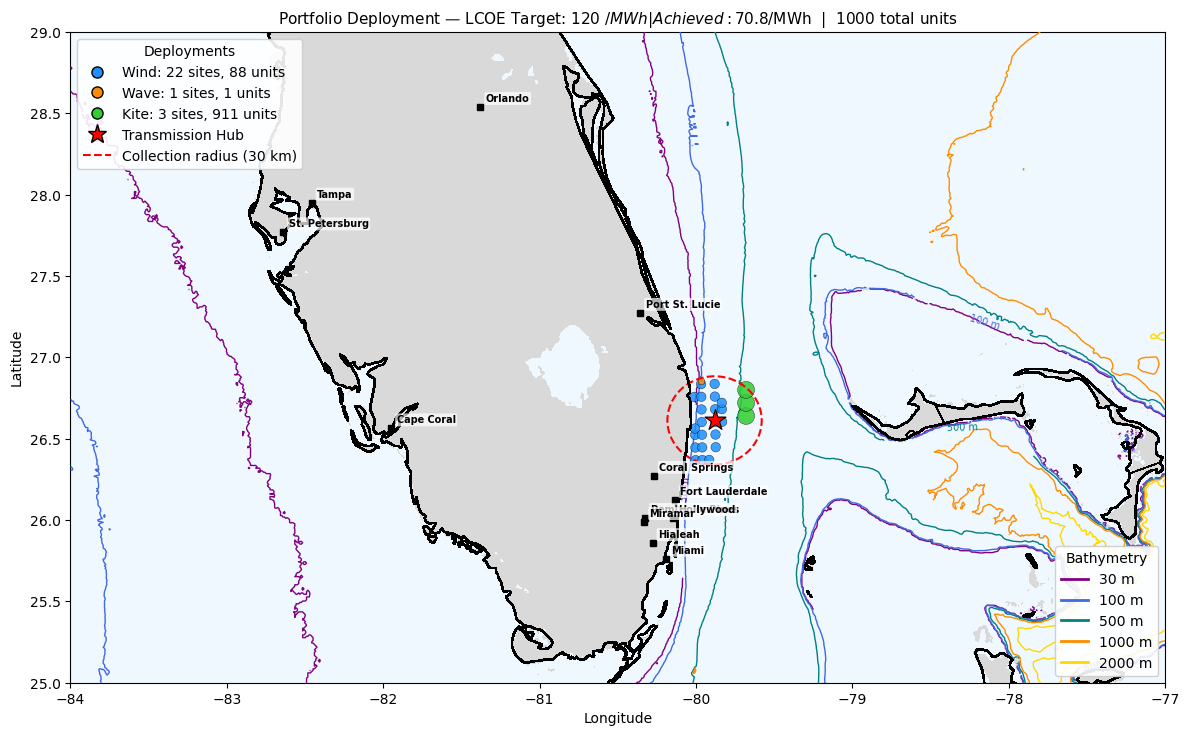

Done.


In [6]:
"""
Plot_Portfolio_Standalone.py
============================
Standalone deployment-map plotter for a single per-LCOE portfolio .npz file.
Draws coastline, state borders, and bathymetry contours.

The per-LCOE .npz files store decision variables (Y_Wind, Y_Wave, Y_Kite,
s_Transmission) but NOT the site lat/longs.  We reload those from the
original tech-design .npz files specified in the CONFIGURATION block below.

Usage:
    1. Set the paths in the CONFIGURATION block.
    2. Run:  python Plot_Portfolio_Standalone.py
       — or paste into a Jupyter notebook (add %matplotlib inline at top).
"""

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xarray as xr
from matplotlib.lines import Line2D
from pathlib import Path

# ======================================================================
# CONFIGURATION — edit these paths for your machine / run
# ======================================================================

# Portfolio per-LCOE shard to plot
PORTFOLIO_NPZ = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\GenPU_ATB_18MW_2030_Florida_Florida_HalfScale_63.62_KitePower_Design3_Florida_100m_Transmission_1200MW_Florida\LCOE_120\Portfolio_LCOE_120.npz"

# --- Original tech-design files (same ones passed to the optimizer) ---
# These contain the LatLong arrays that correspond to Y_Wind, Y_Wave, Y_Kite.
# Leave a list EMPTY if that technology was not used in the run.

PathWindDesigns = [
    r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Wind\MaxLCOE180Res0.08dist30km\GenPU_ATB_18MW_2030_Florida.npz",
]

PathWaveDesigns = [
    r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Wave\ByState_Uniform_30km\Florida_HalfScale_63.62.npz",
]

PathKiteDesigns = [
    r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Current\ByState_MaxLCOE120\KitePower_Design3_Florida_100m.npz",
]

PathTransmissionDesign = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Transmission\ByState\Transmission_1200MW_Florida.npz"

# --- Geospatial overlays ---
DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"

# Collection radius in km
MAX_COLLECTION_RADIUS_KM = 30.0

# Output — set to a folder path to save a PNG, or None to just display
SAVE_DIR  = None        # e.g. r"C:\Users\rmiller9\Documents\East Coast Model\Plots"
SAVE_NAME = "Plot_DeploymentMap_Geo.png"

# Axis padding (degrees) around deployed sites
PAD = 2.0

# ======================================================================
# STYLE
# ======================================================================

TECH_COLORS = {
    "Wind":    "dodgerblue",
    "Kite":    "limegreen",
    "Wave":    "darkorange",
    "Coaxial": "mediumorchid",
    "Tidal":   "crimson",
}

DEPTH_LEVELS = [30, 100, 500, 1000, 2000]
DEPTH_COLORS = {
    30:   "purple",
    100:  "royalblue",
    500:  "teal",
    1000: "darkorange",
    2000: "gold",
}

# ======================================================================
# HELPERS
# ======================================================================

def km_to_deg_lon(km, lat_deg):
    return km / (111.32 * np.cos(np.radians(lat_deg)))

def km_to_deg_lat(km):
    return km / 110.574


def _load_latlong_concat(design_paths):
    """Load and concatenate LatLong arrays from a list of tech-design .npz files."""
    all_ll = []
    for p in design_paths:
        D = np.load(p, allow_pickle=True)
        all_ll.append(D["LatLong"])
        D.close()
    if len(all_ll) == 0:
        return np.empty((0, 2))
    return np.concatenate(all_ll, axis=0)

# ======================================================================
# LOAD GEO DATA
# ======================================================================

print("Loading geospatial overlays …")

ds      = xr.open_dataset(DEPTH_NC)
lat_d   = ds["lat"].values[::2]
lon_d   = ds["lon"].values[::2]
depth   = ds["depth"].values[::2, ::2]
LonGrid, LatGrid = np.meshgrid(lon_d, lat_d)
ds.close()

coast   = gpd.read_file(COAST_SHP)
borders = gpd.read_file(BORDERS_SHP)
coast   = coast.set_crs(epsg=4326)   if coast.crs is None   else coast.to_crs(epsg=4326)
borders = borders.set_crs(epsg=4326) if borders.crs is None else borders.to_crs(epsg=4326)

# ======================================================================
# LOAD SITE LAT/LONGS FROM TECH DESIGN FILES
# ======================================================================

print("Loading site coordinates from tech-design files …")
WindLatLong = _load_latlong_concat(PathWindDesigns)
WaveLatLong = _load_latlong_concat(PathWaveDesigns)
KiteLatLong = _load_latlong_concat(PathKiteDesigns)

TData        = np.load(PathTransmissionDesign, allow_pickle=True)["TransmissionLineParameters"].item()
TransLatLong = TData["TL_LatLong"]
print(f"  Wind sites:  {len(WindLatLong)}")
print(f"  Wave sites:  {len(WaveLatLong)}")
print(f"  Kite sites:  {len(KiteLatLong)}")
print(f"  Trans hubs:  {len(TransLatLong)}")

# ======================================================================
# LOAD PORTFOLIO DECISION VARIABLES
# ======================================================================

print(f"Loading portfolio: {PORTFOLIO_NPZ}")
Z = np.load(PORTFOLIO_NPZ, allow_pickle=True)

lcoe_target   = float(Z["LCOE_Target"])
lcoe_achieved = float(Z["LCOE_Achieved"])

Y_Wind = Z["Y_Wind"]          # (num_wind_sites,) — units deployed per site
Y_Wave = Z["Y_Wave"]          # (num_wave_sites,)
Y_Kite = Z["Y_Kite"]          # (num_kite_sites,)
s_arr  = Z["s_Transmission"]  # (num_trans_hubs,) — binary, one selected
Z.close()

# Sanity checks
assert len(Y_Wind) == len(WindLatLong), \
    f"Y_Wind length ({len(Y_Wind)}) != WindLatLong length ({len(WindLatLong)}). Check design paths."
assert len(Y_Wave) == len(WaveLatLong), \
    f"Y_Wave length ({len(Y_Wave)}) != WaveLatLong length ({len(WaveLatLong)}). Check design paths."
assert len(Y_Kite) == len(KiteLatLong), \
    f"Y_Kite length ({len(Y_Kite)}) != KiteLatLong length ({len(KiteLatLong)}). Check design paths."
assert len(s_arr) == len(TransLatLong), \
    f"s_Transmission length ({len(s_arr)}) != TransLatLong length ({len(TransLatLong)}). Check transmission path."

print("All dimension checks passed.")

# ======================================================================
# PLOT
# ======================================================================

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor("#d9d9d9")  # grey land background

# Fill ocean areas with blue using the bathymetry grid.
# Anywhere depth > 0 is ocean; contourf with a single level [0, max] does the trick.
ax.contourf(LonGrid, LatGrid, depth,
            levels=[0, depth.max()], colors=["aliceblue"], zorder=1)

legend_handles = []
all_lons = []
all_lats = []
total_units = 0

# --- Deployed sites per technology ---
tech_data = [
    ("Wind", Y_Wind, WindLatLong),
    ("Wave", Y_Wave, WaveLatLong),
    ("Kite", Y_Kite, KiteLatLong),
]

for tech_name, Y_arr, LatLong in tech_data:
    if len(Y_arr) == 0:
        continue
    active = np.where(Y_arr > 0.5)[0]
    if len(active) == 0:
        continue

    ll    = LatLong[active]
    units = Y_arr[active]
    color = TECH_COLORS.get(tech_name, "gray")
    sizes = np.clip(15 + units * 8, 15, 150)

    ax.scatter(ll[:, 1], ll[:, 0], s=sizes, c=color,
               edgecolors="black", linewidths=0.3, alpha=0.85, zorder=4)

    n_sites = len(units)
    n_units = int(units.sum())
    total_units += n_units
    legend_handles.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
               markeredgecolor="black", markersize=8,
               label=f"{tech_name}: {n_sites} sites, {n_units} units")
    )

    all_lons.extend(ll[:, 1].tolist())
    all_lats.extend(ll[:, 0].tolist())

# --- Transmission hub ---
hub_idx = np.argmax(s_arr)
hub_ll  = TransLatLong[hub_idx]

ax.scatter(hub_ll[1], hub_ll[0], s=250, c="red", marker="*",
           edgecolors="black", linewidths=0.8, zorder=6)
legend_handles.append(
    Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
           markeredgecolor="black", markersize=14, label="Transmission Hub")
)
all_lons.append(hub_ll[1])
all_lats.append(hub_ll[0])

# --- Collection radius circle ---
r_lat = km_to_deg_lat(MAX_COLLECTION_RADIUS_KM)
r_lon = km_to_deg_lon(MAX_COLLECTION_RADIUS_KM, hub_ll[0])
circle = mpatches.Ellipse(
    (hub_ll[1], hub_ll[0]), width=2 * r_lon, height=2 * r_lat,
    fill=False, edgecolor="red", linewidth=1.5, linestyle="--", zorder=5,
)
ax.add_patch(circle)
legend_handles.append(
    Line2D([0], [0], color="red", linestyle="--", lw=1.5,
           label=f"Collection radius ({MAX_COLLECTION_RADIUS_KM:.0f} km)")
)

# --- Domain bounds ---
# Fixed bounding box to show full Florida + offshore area.
# Switch to the auto-fit lines below for other states.
xlim = (-84.0, -77.0)
ylim = (25.0, 29.0)
# Auto-fit alternative (uncomment for non-Florida runs):
# xlim = (min(all_lons) - PAD, max(all_lons) + PAD)
# ylim = (min(all_lats) - PAD, max(all_lats) + PAD)

# --- Geospatial overlays (depth contours + coastline + borders) ---
for lvl in DEPTH_LEVELS:
    cs = ax.contour(LonGrid, LatGrid, depth,
                    levels=[lvl], colors=[DEPTH_COLORS[lvl]],
                    linewidths=1.0, zorder=3)
    ax.clabel(cs, inline=True, fontsize=7, fmt={lvl: f"{lvl} m"})

coast.plot(ax=ax, linewidth=1.2, color="black", zorder=5, antialiased=False)
borders.plot(ax=ax, linewidth=0.6, color="black", zorder=5, antialiased=False)

# --- Florida cities with population > 100,000 ---
FL_CITIES = [
    ("Jacksonville",    30.3322, -81.6557),
    ("Miami",           25.7617, -80.1918),
    ("Tampa",           27.9506, -82.4572),
    ("Orlando",         28.5383, -81.3792),
    ("St. Petersburg",  27.7676, -82.6403),
    ("Hialeah",         25.8576, -80.2781),
    ("Port St. Lucie",  27.2730, -80.3582),
    ("Cape Coral",      26.5629, -81.9495),
    ("Tallahassee",     30.4383, -84.2807),
    ("Fort Lauderdale", 26.1224, -80.1373),
    ("Pembroke Pines",  26.0128, -80.3241),
    ("Hollywood",       26.0112, -80.1495),
    ("Gainesville",     29.6516, -82.3248),
    ("Miramar",         25.9873, -80.3322),
    ("Coral Springs",   26.2712, -80.2706),
]

for city_name, lat, lon in FL_CITIES:
    if xlim[0] <= lon <= xlim[1] and ylim[0] <= lat <= ylim[1]:
        ax.plot(lon, lat, "s", color="black", markersize=4, zorder=7)
        ax.annotate(city_name, (lon, lat), fontsize=7, fontweight="bold",
                    xytext=(4, 4), textcoords="offset points", zorder=7,
                    color="black",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# --- Legends ---
depth_handles = [
    Line2D([0], [0], color=DEPTH_COLORS[l], lw=2, label=f"{l} m")
    for l in DEPTH_LEVELS
]

leg1 = ax.legend(handles=legend_handles, loc="upper left",
                 frameon=True, framealpha=0.9, facecolor="white",
                 title="Deployments")
ax.add_artist(leg1)

ax.legend(handles=depth_handles, loc="lower right",
          frameon=True, framealpha=0.9, facecolor="white",
          title="Bathymetry")

ax.set_title(
    f"Portfolio Deployment — LCOE Target: {lcoe_target:.0f} $/MWh"
    f"  |  Achieved: {lcoe_achieved:.1f} $/MWh"
    f"  |  {total_units} total units",
    fontsize=11,
)

plt.tight_layout()

# --- Save / show ---
if SAVE_DIR:
    import os
    out = os.path.join(SAVE_DIR, SAVE_NAME)
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved → {out}")

plt.show()
print("Done.")

Plotting code for NC

Loading geospatial overlays …
Loading site coordinates from tech-design files …
  Wind sites:  596
  Wave sites:  380
  Kite sites:  0
  Trans hubs:  543
Loading portfolio: C:\Users\rmiller9\Documents\East Coast Model\Portfolios\WEC Runs different costs\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz
All dimension checks passed.


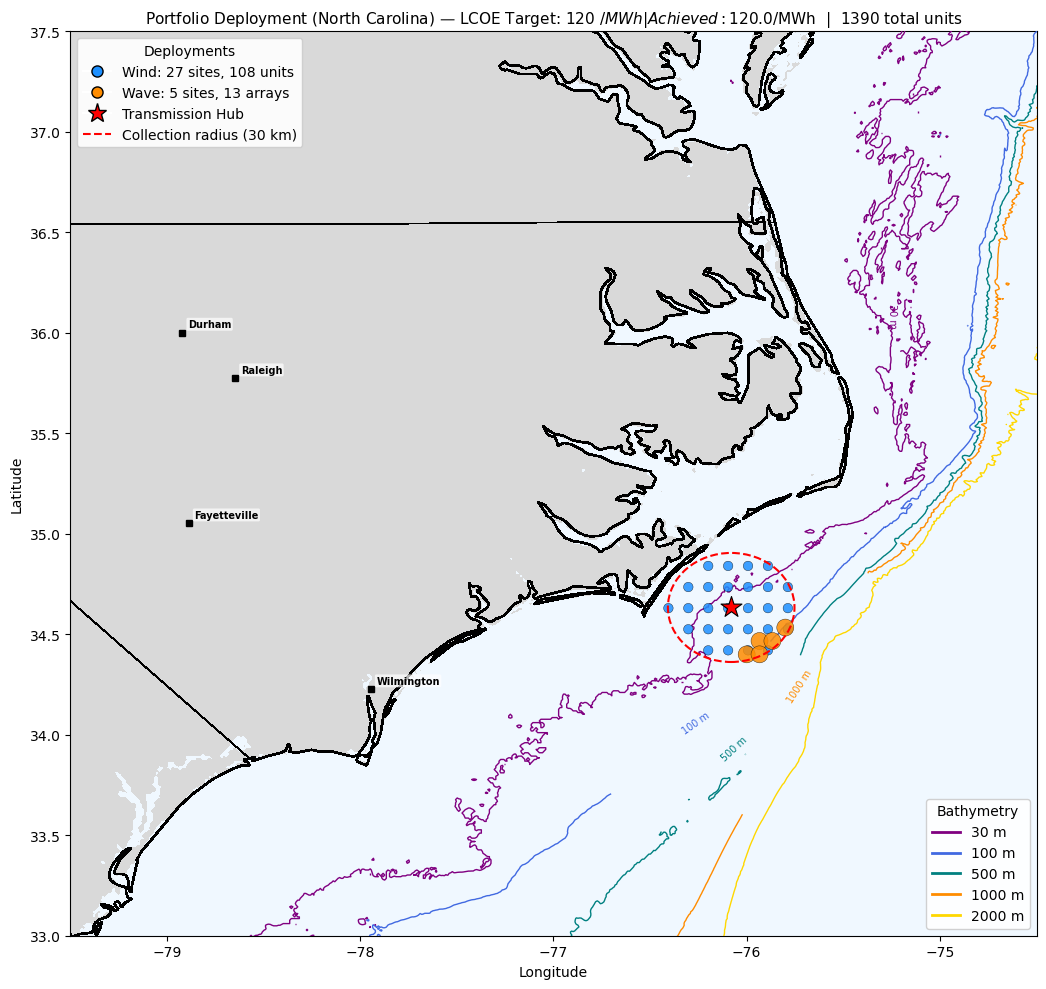

Done.


In [3]:
"""
Plot_Portfolio_Standalone_NC.py
===============================
Standalone deployment-map plotter for a single per-LCOE portfolio .npz file,
retargeted to the North Carolina offshore domain.

Draws coastline, state borders, bathymetry contours, and populated places
pulled from the Natural Earth ne_10m_populated_places shapefile (instead of a
hardcoded city list).

The per-LCOE .npz files store decision variables (Y_Wind, Y_Wave, Y_Kite,
s_Transmission) but NOT the site lat/longs. Those are reloaded from the
original tech-design .npz files specified in the CONFIGURATION block.

Usage:
    1. Set the paths in the CONFIGURATION block.
    2. Run:  python Plot_Portfolio_Standalone_NC.py
       — or paste into a Jupyter notebook (add %matplotlib inline at top).
"""

import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xarray as xr
from matplotlib.lines import Line2D
import math

# ======================================================================
# CONFIGURATION — edit these paths for your machine / run
# ======================================================================

# Portfolio per-LCOE shard to plot (North Carolina run)
PORTFOLIO_NPZ = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\WEC Runs different costs\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz"

# --- Original tech-design files (same ones passed to the optimizer) ---
# These contain the LatLong arrays that correspond to Y_Wind, Y_Wave, Y_Kite.
# Leave a list EMPTY if that technology was not used in the run.

PathWindDesigns = [
    r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Wind/Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030.npz",
]

PathWaveDesigns = [
    r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Wave/2009_2013_HalfScale_63.62.npz",
]

# Wind + wave only by default. Add a path here if a kite design was used.
PathKiteDesigns = [
]

PathTransmissionDesign = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Transmission/Transmission_1200MW.npz"

# --- Geospatial overlays ---
DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
PLACES_SHP  = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_populated_places.shp"

# Collection radius in km
MAX_COLLECTION_RADIUS_KM = 30.0

# City filter (Natural Earth populated places)
CITY_STATE   = "North Carolina"   # match against ADM1NAME; set None to skip the state filter
CITY_POP_MIN = 100_000            # minimum POP_MAX to label; set None to skip

# Domain bounds (degrees). Set USE_AUTO_FIT = True to frame to deployed sites instead.
USE_AUTO_FIT = False
XLIM = (-79.5, -74.5)
YLIM = (33.0, 37.5)
PAD  = 2.0  # padding (deg) used only when USE_AUTO_FIT is True

# Output — set to a folder path to save a PNG, or None to just display
SAVE_DIR  = None        # e.g. r"C:\Users\rmiller9\Documents\East Coast Model\Plots"
SAVE_NAME = "Plot_DeploymentMap_NC.png"

# ======================================================================
# STYLE
# ======================================================================

TECH_COLORS = {
    "Wind":    "dodgerblue",
    "Kite":    "limegreen",
    "Wave":    "darkorange",
    "Coaxial": "mediumorchid",
    "Tidal":   "crimson",
}

DEPTH_LEVELS = [30, 100, 500, 1000, 2000]
DEPTH_COLORS = {
    30:   "purple",
    100:  "royalblue",
    500:  "teal",
    1000: "darkorange",
    2000: "gold",
}

# ======================================================================
# HELPERS
# ======================================================================

def km_to_deg_lon(km, lat_deg):
    return km / (111.32 * np.cos(np.radians(lat_deg)))

def km_to_deg_lat(km):
    return km / 110.574


def _load_latlong_concat(design_paths):
    """Load and concatenate LatLong arrays from a list of tech-design .npz files."""
    all_ll = []
    for p in design_paths:
        D = np.load(p, allow_pickle=True)
        all_ll.append(D["LatLong"])
        D.close()
    if len(all_ll) == 0:
        return np.empty((0, 2))
    return np.concatenate(all_ll, axis=0)

# ======================================================================
# LOAD GEO DATA
# ======================================================================

print("Loading geospatial overlays …")

ds      = xr.open_dataset(DEPTH_NC)
lat_d   = ds["lat"].values[::2]
lon_d   = ds["lon"].values[::2]
depth   = ds["depth"].values[::2, ::2]
LonGrid, LatGrid = np.meshgrid(lon_d, lat_d)
ds.close()

coast   = gpd.read_file(COAST_SHP)
borders = gpd.read_file(BORDERS_SHP)
places  = gpd.read_file(PLACES_SHP)

coast   = coast.set_crs(epsg=4326)   if coast.crs is None   else coast.to_crs(epsg=4326)
borders = borders.set_crs(epsg=4326) if borders.crs is None else borders.to_crs(epsg=4326)
places  = places.set_crs(epsg=4326)  if places.crs is None  else places.to_crs(epsg=4326)

# ======================================================================
# LOAD SITE LAT/LONGS FROM TECH DESIGN FILES
# ======================================================================

print("Loading site coordinates from tech-design files …")
WindLatLong = _load_latlong_concat(PathWindDesigns)
WaveLatLong = _load_latlong_concat(PathWaveDesigns)
KiteLatLong = _load_latlong_concat(PathKiteDesigns)

TData        = np.load(PathTransmissionDesign, allow_pickle=True)["TransmissionLineParameters"].item()
TransLatLong = TData["TL_LatLong"]
print(f"  Wind sites:  {len(WindLatLong)}")
print(f"  Wave sites:  {len(WaveLatLong)}")
print(f"  Kite sites:  {len(KiteLatLong)}")
print(f"  Trans hubs:  {len(TransLatLong)}")

# ======================================================================
# LOAD PORTFOLIO DECISION VARIABLES
# ======================================================================

print(f"Loading portfolio: {PORTFOLIO_NPZ}")
Z = np.load(PORTFOLIO_NPZ, allow_pickle=True)

lcoe_target   = float(Z["LCOE_Target"])
lcoe_achieved = float(Z["LCOE_Achieved"])

Y_Wind = Z["Y_Wind"]          # (num_wind_sites,) — units deployed per site
Y_Wave = Z["Y_Wave"]          # (num_wave_sites,)
Y_Kite = Z["Y_Kite"] if "Y_Kite" in Z.files else np.empty((0,))
s_arr  = Z["s_Transmission"]  # (num_trans_hubs,) — binary, one selected
Z.close()

# Sanity checks
assert len(Y_Wind) == len(WindLatLong), \
    f"Y_Wind length ({len(Y_Wind)}) != WindLatLong length ({len(WindLatLong)}). Check design paths."
assert len(Y_Wave) == len(WaveLatLong), \
    f"Y_Wave length ({len(Y_Wave)}) != WaveLatLong length ({len(WaveLatLong)}). Check design paths."
assert len(Y_Kite) == len(KiteLatLong), \
    f"Y_Kite length ({len(Y_Kite)}) != KiteLatLong length ({len(KiteLatLong)}). Check design paths."
assert len(s_arr) == len(TransLatLong), \
    f"s_Transmission length ({len(s_arr)}) != TransLatLong length ({len(TransLatLong)}). Check transmission path."

print("All dimension checks passed.")

# ======================================================================
# PLOT
# ======================================================================

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor("#d9d9d9")  # grey land background

# Fill ocean areas with blue using the bathymetry grid.
ax.contourf(LonGrid, LatGrid, depth,
            levels=[0, depth.max()], colors=["aliceblue"], zorder=1)

legend_handles = []
all_lons = []
all_lats = []
total_units = 0

# --- Deployed sites per technology ---
tech_data = [
    ("Wind", Y_Wind, WindLatLong),
    ("Wave", Y_Wave, WaveLatLong),
    ("Kite", Y_Kite, KiteLatLong),
]

for tech_name, Y_arr, LatLong in tech_data:
    if len(Y_arr) == 0:
        continue
    active = np.where(Y_arr > 0.5)[0]
    if len(active) == 0:
        continue

    ll    = LatLong[active]
    units = Y_arr[active]
    color = TECH_COLORS.get(tech_name, "gray")
    sizes = np.clip(15 + units * 8, 15, 150)

    ax.scatter(ll[:, 1], ll[:, 0], s=sizes, c=color,
               edgecolors="black", linewidths=0.3, alpha=0.85, zorder=4)

    n_sites = len(units)
    n_units = int(units.sum())
    total_units += n_units

    if tech_name == "Wave":
        n_arrays = math.ceil(n_units / 100)
        label = f"{tech_name}: {n_sites} sites, {n_arrays} arrays"
    else:
        label = f"{tech_name}: {n_sites} sites, {n_units} units"

    legend_handles.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
               markeredgecolor="black", markersize=8,
               label=label)
    )

    all_lons.extend(ll[:, 1].tolist())
    all_lats.extend(ll[:, 0].tolist())

# --- Transmission hub ---
hub_idx = np.argmax(s_arr)
hub_ll  = TransLatLong[hub_idx]

ax.scatter(hub_ll[1], hub_ll[0], s=250, c="red", marker="*",
           edgecolors="black", linewidths=0.8, zorder=6)
legend_handles.append(
    Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
           markeredgecolor="black", markersize=14, label="Transmission Hub")
)
all_lons.append(hub_ll[1])
all_lats.append(hub_ll[0])

# --- Collection radius circle ---
r_lat = km_to_deg_lat(MAX_COLLECTION_RADIUS_KM)
r_lon = km_to_deg_lon(MAX_COLLECTION_RADIUS_KM, hub_ll[0])
circle = mpatches.Ellipse(
    (hub_ll[1], hub_ll[0]), width=2 * r_lon, height=2 * r_lat,
    fill=False, edgecolor="red", linewidth=1.5, linestyle="--", zorder=5,
)
ax.add_patch(circle)
legend_handles.append(
    Line2D([0], [0], color="red", linestyle="--", lw=1.5,
           label=f"Collection radius ({MAX_COLLECTION_RADIUS_KM:.0f} km)")
)

# --- Domain bounds ---
if USE_AUTO_FIT and all_lons:
    xlim = (min(all_lons) - PAD, max(all_lons) + PAD)
    ylim = (min(all_lats) - PAD, max(all_lats) + PAD)
else:
    xlim = XLIM
    ylim = YLIM

# --- Geospatial overlays (depth contours + coastline + borders) ---
for lvl in DEPTH_LEVELS:
    cs = ax.contour(LonGrid, LatGrid, depth,
                    levels=[lvl], colors=[DEPTH_COLORS[lvl]],
                    linewidths=1.0, zorder=3)
    ax.clabel(cs, inline=True, fontsize=7, fmt={lvl: f"{lvl} m"})

coast.plot(ax=ax, linewidth=1.2, color="black", zorder=5, antialiased=False)
borders.plot(ax=ax, linewidth=0.6, color="black", zorder=5, antialiased=False)

# --- Populated places from Natural Earth ---
sub = places.copy()
if CITY_STATE is not None and "ADM1NAME" in sub.columns:
    sub = sub[sub["ADM1NAME"] == CITY_STATE]
if CITY_POP_MIN is not None and "POP_MAX" in sub.columns:
    sub = sub[sub["POP_MAX"] >= CITY_POP_MIN]

for _, row in sub.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y
    if xlim[0] <= lon <= xlim[1] and ylim[0] <= lat <= ylim[1]:
        name = row.get("NAME", "")
        ax.plot(lon, lat, "s", color="black", markersize=4, zorder=7)
        ax.annotate(name, (lon, lat), fontsize=7, fontweight="bold",
                    xytext=(4, 4), textcoords="offset points", zorder=7,
                    color="black",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# --- Legends ---
depth_handles = [
    Line2D([0], [0], color=DEPTH_COLORS[l], lw=2, label=f"{l} m")
    for l in DEPTH_LEVELS
]

leg1 = ax.legend(handles=legend_handles, loc="upper left",
                 frameon=True, framealpha=0.9, facecolor="white",
                 title="Deployments")
ax.add_artist(leg1)

ax.legend(handles=depth_handles, loc="lower right",
          frameon=True, framealpha=0.9, facecolor="white",
          title="Bathymetry")

ax.set_title(
    f"Portfolio Deployment (North Carolina) — LCOE Target: {lcoe_target:.0f} $/MWh"
    f"  |  Achieved: {lcoe_achieved:.1f} $/MWh"
    f"  |  {total_units} total units",
    fontsize=11,
)

plt.tight_layout()

# --- Save / show ---
if SAVE_DIR:
    out = os.path.join(SAVE_DIR, SAVE_NAME)
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved → {out}")

plt.show()
print("Done.")

plot 4 scenarios at once

Loading shared geospatial overlays …
Drawing: Wind/WEC Base Case
Drawing: Wind/WEC 10% Cost
Drawing: Wind Only
Drawing: WEC Only 10% Cost


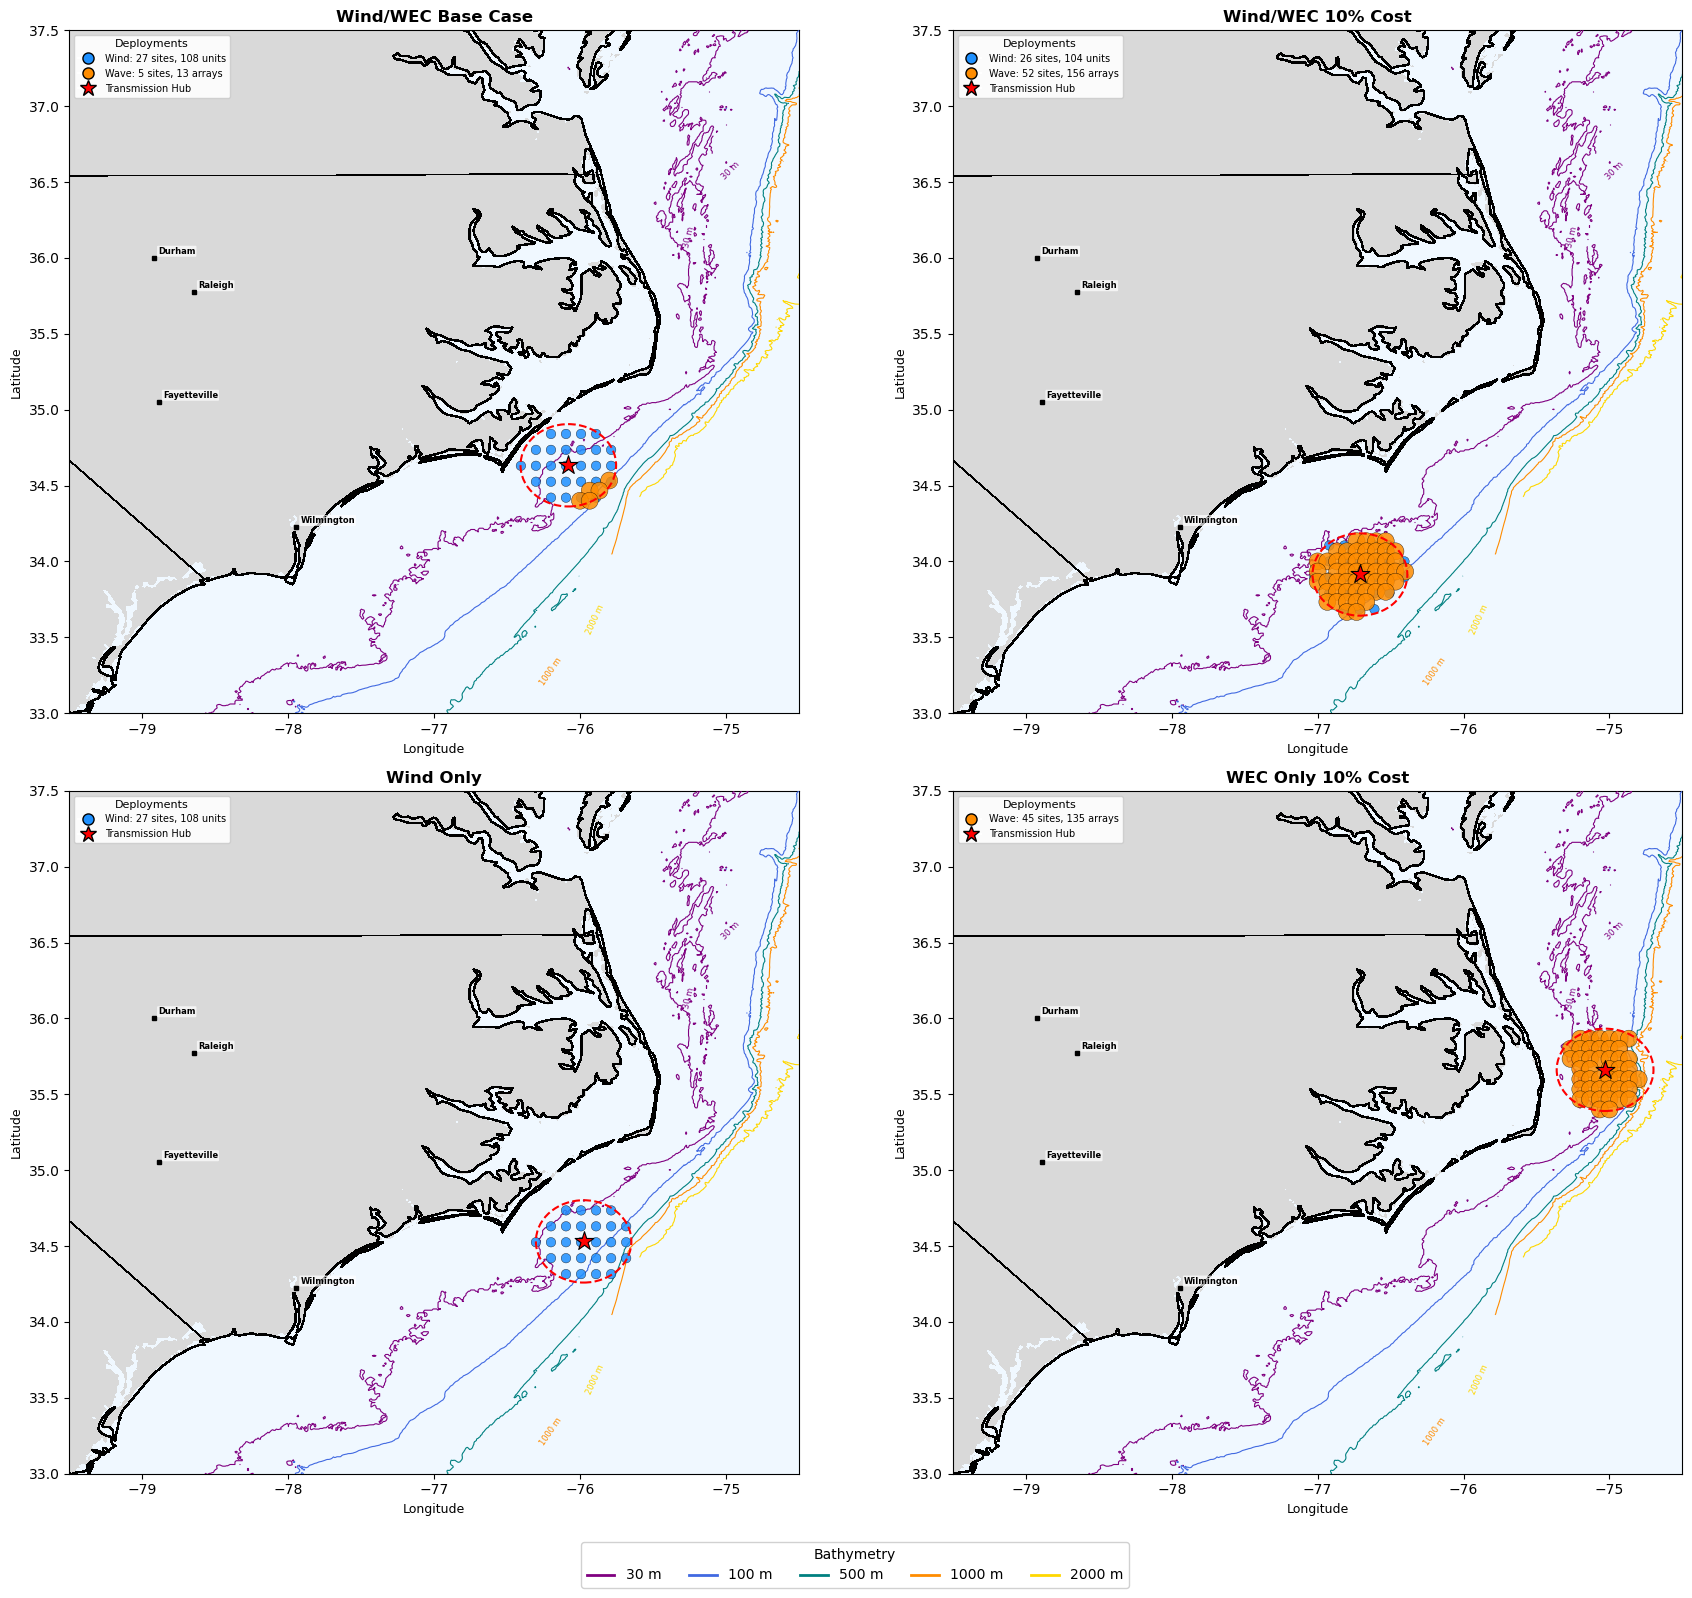

Done.


In [6]:
"""
Plot_Portfolio_Subplots_NC.py
=============================
Plots four North Carolina portfolio deployment maps as a 2x2 grid of subplots,
one per simulation case. Each subplot title is just the case name.

Cases shown:
    - Wind/WEC Base Case
    - Wind/WEC 10% Cost
    - Wind Only
    - WEC Only 10% Cost

The per-LCOE .npz files store decision variables (Y_Wind, Y_Wave, Y_Kite,
s_Transmission) but NOT the site lat/longs. Those are reloaded from the
original tech-design .npz files (the same ones passed to the optimizer).

Notebook use: paste into a cell, add %matplotlib inline at the top.
"""

import os
import math
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xarray as xr
from matplotlib.lines import Line2D

# ======================================================================
# SHARED TECH-DESIGN FILES (carry the LatLong arrays) — same for all cases
# ======================================================================

WIND_DESIGN  = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Wind/Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030.npz"
WAVE_DESIGN  = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Wave/2009_2013_HalfScale_63.62.npz"
TRANS_DESIGN = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Transmission/Transmission_1200MW.npz"

# ======================================================================
# GEOSPATIAL OVERLAYS (shared)
# ======================================================================

DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
PLACES_SHP  = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_populated_places.shp"

# Collection radius in km
MAX_COLLECTION_RADIUS_KM = 30.0

# City filter (Natural Earth populated places)
CITY_STATE   = "North Carolina"   # match against ADM1NAME; set None to skip
CITY_POP_MIN = 100_000            # minimum POP_MAX to label; set None to skip

# Domain bounds (degrees) — fixed for all panels so they're comparable
XLIM = (-79.5, -74.5)
YLIM = (33.0, 37.5)

WAVE_DEVICES_PER_ARRAY = 100

# Output — set to a path to save a PNG, or None to just display
SAVE_PATH = None  # e.g. r"C:\Users\rmiller9\Documents\East Coast Model\Plots\Deployment_2x2.png"

# ======================================================================
# CASES — one dict per subplot
# ======================================================================

PORT = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios"

CASES = [
    {
        "title": "Wind/WEC Base Case",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz",
        "wind":  [WIND_DESIGN],
        "wave":  [WAVE_DESIGN],
        "kite":  [],
        "trans": TRANS_DESIGN,
    },
    {
        "title": "Wind/WEC 10% Cost",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz",
        "wind":  [WIND_DESIGN],
        "wave":  [WAVE_DESIGN],
        "kite":  [],
        "trans": TRANS_DESIGN,
    },
    {
        "title": "Wind Only",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5\LCOE_120\Portfolio_LCOE_120.npz",
        "wind":  [WIND_DESIGN],
        "wave":  [],
        "kite":  [],
        "trans": TRANS_DESIGN,
    },
    {
        "title": "WEC Only 10% Cost",
        "portfolio": rf"{PORT}\2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz",
        "wind":  [],
        "wave":  [WAVE_DESIGN],
        "kite":  [],
        "trans": TRANS_DESIGN,
    },
]

# ======================================================================
# STYLE
# ======================================================================

TECH_COLORS = {
    "Wind":    "dodgerblue",
    "Kite":    "limegreen",
    "Wave":    "darkorange",
    "Coaxial": "mediumorchid",
    "Tidal":   "crimson",
}

DEPTH_LEVELS = [30, 100, 500, 1000, 2000]
DEPTH_COLORS = {
    30:   "purple",
    100:  "royalblue",
    500:  "teal",
    1000: "darkorange",
    2000: "gold",
}

# ======================================================================
# HELPERS
# ======================================================================

def km_to_deg_lon(km, lat_deg):
    return km / (111.32 * np.cos(np.radians(lat_deg)))

def km_to_deg_lat(km):
    return km / 110.574


def _load_latlong_concat(design_paths):
    """Load and concatenate LatLong arrays from a list of tech-design .npz files."""
    all_ll = []
    for p in design_paths:
        D = np.load(p, allow_pickle=True)
        all_ll.append(D["LatLong"])
        D.close()
    if len(all_ll) == 0:
        return np.empty((0, 2))
    return np.concatenate(all_ll, axis=0)

# ======================================================================
# LOAD SHARED GEO DATA ONCE
# ======================================================================

print("Loading shared geospatial overlays …")

ds      = xr.open_dataset(DEPTH_NC)
lat_d   = ds["lat"].values[::2]
lon_d   = ds["lon"].values[::2]
depth   = ds["depth"].values[::2, ::2]
LonGrid, LatGrid = np.meshgrid(lon_d, lat_d)
ds.close()

coast   = gpd.read_file(COAST_SHP)
borders = gpd.read_file(BORDERS_SHP)
places  = gpd.read_file(PLACES_SHP)
coast   = coast.set_crs(epsg=4326)   if coast.crs is None   else coast.to_crs(epsg=4326)
borders = borders.set_crs(epsg=4326) if borders.crs is None else borders.to_crs(epsg=4326)
places  = places.set_crs(epsg=4326)  if places.crs is None  else places.to_crs(epsg=4326)

# Pre-filter populated places once
places_sub = places.copy()
if CITY_STATE is not None and "ADM1NAME" in places_sub.columns:
    places_sub = places_sub[places_sub["ADM1NAME"] == CITY_STATE]
if CITY_POP_MIN is not None and "POP_MAX" in places_sub.columns:
    places_sub = places_sub[places_sub["POP_MAX"] >= CITY_POP_MIN]

# ======================================================================
# DRAW ONE CASE ONTO A GIVEN AXIS
# ======================================================================

def draw_case(ax, case):
    # --- Load site coordinates ---
    WindLatLong = _load_latlong_concat(case["wind"])
    WaveLatLong = _load_latlong_concat(case["wave"])
    KiteLatLong = _load_latlong_concat(case["kite"])

    TData        = np.load(case["trans"], allow_pickle=True)["TransmissionLineParameters"].item()
    TransLatLong = TData["TL_LatLong"]

    # --- Load portfolio decision variables ---
    Z = np.load(case["portfolio"], allow_pickle=True)
    Y_Wind = Z["Y_Wind"] if "Y_Wind" in Z.files else np.empty((0,))
    Y_Wave = Z["Y_Wave"] if "Y_Wave" in Z.files else np.empty((0,))
    Y_Kite = Z["Y_Kite"] if "Y_Kite" in Z.files else np.empty((0,))
    s_arr  = Z["s_Transmission"]
    Z.close()

    # --- Background ocean ---
    ax.set_facecolor("#d9d9d9")
    ax.contourf(LonGrid, LatGrid, depth,
                levels=[0, depth.max()], colors=["aliceblue"], zorder=1)

    legend_handles = []

    tech_data = [
        ("Wind", Y_Wind, WindLatLong),
        ("Wave", Y_Wave, WaveLatLong),
        ("Kite", Y_Kite, KiteLatLong),
    ]

    for tech_name, Y_arr, LatLong in tech_data:
        if len(Y_arr) == 0 or len(LatLong) == 0:
            continue
        active = np.where(Y_arr > 0.5)[0]
        if len(active) == 0:
            continue

        ll    = LatLong[active]
        units = Y_arr[active]
        color = TECH_COLORS.get(tech_name, "gray")
        sizes = np.clip(15 + units * 8, 15, 150)

        ax.scatter(ll[:, 1], ll[:, 0], s=sizes, c=color,
                   edgecolors="black", linewidths=0.3, alpha=0.85, zorder=4)

        n_sites = len(units)
        n_units = int(units.sum())
        if tech_name == "Wave":
            n_arrays = math.ceil(n_units / WAVE_DEVICES_PER_ARRAY)
            lbl = f"{tech_name}: {n_sites} sites, {n_arrays} arrays"
        else:
            lbl = f"{tech_name}: {n_sites} sites, {n_units} units"

        legend_handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
                   markeredgecolor="black", markersize=8, label=lbl)
        )

    # --- Transmission hub ---
    hub_idx = np.argmax(s_arr)
    hub_ll  = TransLatLong[hub_idx]
    ax.scatter(hub_ll[1], hub_ll[0], s=200, c="red", marker="*",
               edgecolors="black", linewidths=0.8, zorder=6)
    legend_handles.append(
        Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
               markeredgecolor="black", markersize=12, label="Transmission Hub")
    )

    # --- Collection radius circle ---
    r_lat = km_to_deg_lat(MAX_COLLECTION_RADIUS_KM)
    r_lon = km_to_deg_lon(MAX_COLLECTION_RADIUS_KM, hub_ll[0])
    circle = mpatches.Ellipse(
        (hub_ll[1], hub_ll[0]), width=2 * r_lon, height=2 * r_lat,
        fill=False, edgecolor="red", linewidth=1.5, linestyle="--", zorder=5,
    )
    ax.add_patch(circle)

    # --- Depth contours + coast + borders ---
    for lvl in DEPTH_LEVELS:
        cs = ax.contour(LonGrid, LatGrid, depth,
                        levels=[lvl], colors=[DEPTH_COLORS[lvl]],
                        linewidths=0.8, zorder=3)
        ax.clabel(cs, inline=True, fontsize=6, fmt={lvl: f"{lvl} m"})

    coast.plot(ax=ax, linewidth=1.0, color="black", zorder=5, antialiased=False)
    borders.plot(ax=ax, linewidth=0.5, color="black", zorder=5, antialiased=False)

    # --- Populated places ---
    for _, row in places_sub.iterrows():
        lon = row.geometry.x
        lat = row.geometry.y
        if XLIM[0] <= lon <= XLIM[1] and YLIM[0] <= lat <= YLIM[1]:
            name = row.get("NAME", "")
            ax.plot(lon, lat, "s", color="black", markersize=3, zorder=7)
            ax.annotate(name, (lon, lat), fontsize=6, fontweight="bold",
                        xytext=(3, 3), textcoords="offset points", zorder=7,
                        color="black",
                        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.7))

    ax.set_xlim(XLIM)
    ax.set_ylim(YLIM)
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)
    ax.set_title(case["title"], fontsize=12, fontweight="bold")

    ax.legend(handles=legend_handles, loc="upper left",
              frameon=True, framealpha=0.9, facecolor="white", fontsize=7,
              title="Deployments", title_fontsize=8)

# ======================================================================
# BUILD 2x2 GRID
# ======================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for ax, case in zip(axes, CASES):
    print(f"Drawing: {case['title']}")
    draw_case(ax, case)

# Shared bathymetry legend on the figure
depth_handles = [Line2D([0], [0], color=DEPTH_COLORS[l], lw=2, label=f"{l} m")
                 for l in DEPTH_LEVELS]
fig.legend(handles=depth_handles, loc="lower center", ncol=len(DEPTH_LEVELS),
           frameon=True, framealpha=0.9, facecolor="white",
           title="Bathymetry", bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.04, 1, 1])

if SAVE_PATH:
    plt.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
    print(f"Saved -> {SAVE_PATH}")

plt.show()
print("Done.")

2x2 Scenario Deployment maps with resource underlayed under results

Loading wind + wave resource and geo overlays …
Drawing: Wind/WEC Base Case
Drawing: Wind/WEC 10% Cost
Drawing: Wind Only
Drawing: WEC Only 10% Cost


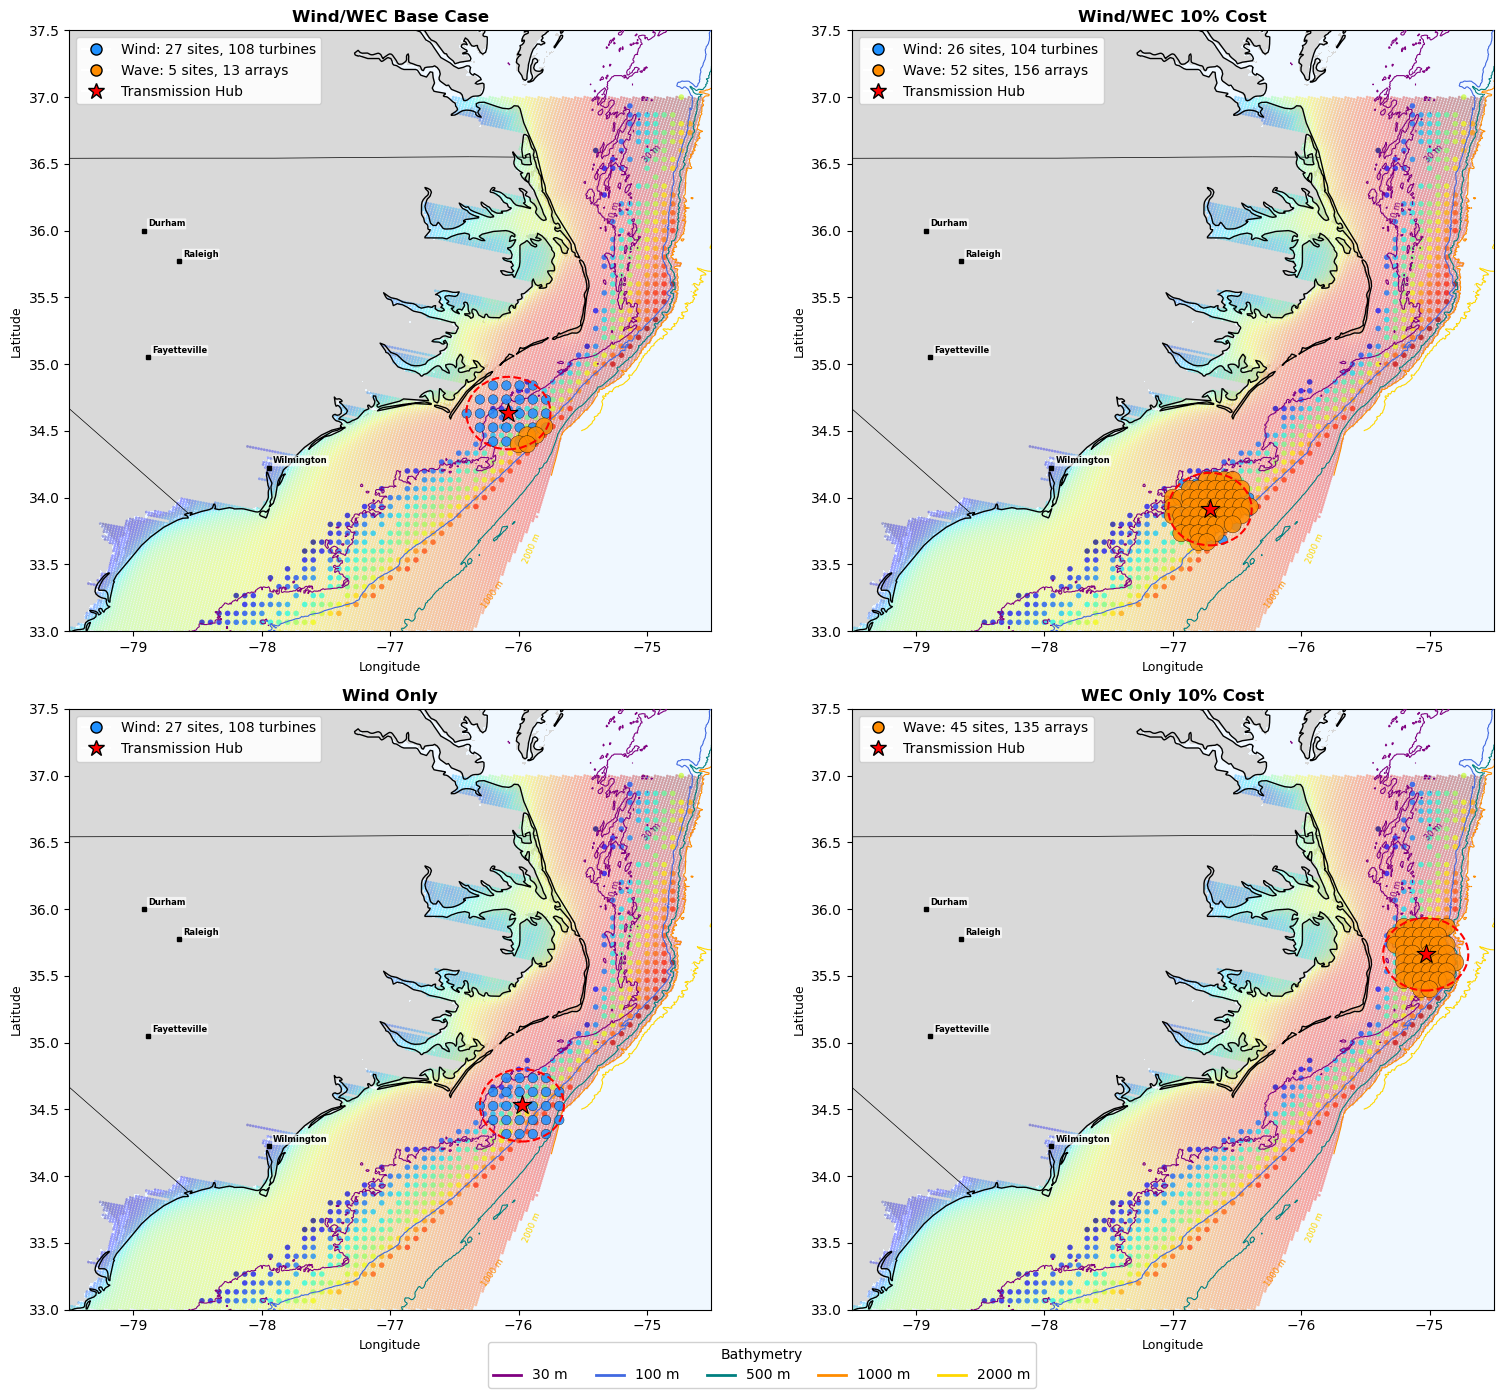

Done.


In [6]:
"""
Plot_Deployment_Over_Resource_NC.py
===================================
Fully self-contained. 2x2 grid of NC portfolio deployment maps (same look as
the deployment plots you liked) with the raw wind + wave resource underlaid,
plotted the SAME WAY as your resource map: offshore scatter points colored by
value (no interpolated fill, so no land coverage and the gradient shows).

Layering (bottom -> top):
    wind scatter -> wave flux scatter -> depth contours -> coast/borders ->
    deployment markers -> transmission hub -> cities.

No colorbars (explain in caption). Panels packed tight.

Notebook use: add %matplotlib inline at the top, then run this cell.
"""

import math
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xarray as xr
from matplotlib.lines import Line2D

# ======================================================================
# RESOURCE DATA SOURCES
# ======================================================================

WIND_RESOURCE_NPZ = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/Organize/Wind/Data_Wind/average_WS_140m.npz"
WAVE_RESOURCE_NPZ = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/InputData/Wave/WWIII_2005_2019.npz"

COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
PLACES_SHP  = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_populated_places.shp"

DEPTH_NC = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"

# ======================================================================
# SHARED TECH-DESIGN FILES
# ======================================================================

WIND_DESIGN  = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Wind/Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030.npz"
WAVE_DESIGN  = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Wave/2009_2013_HalfScale_63.62.npz"
TRANS_DESIGN = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Transmission/Transmission_1200MW.npz"

PORT = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios"

CASES = [
    {
        "title": "Wind/WEC Base Case",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz",
        "wind": [WIND_DESIGN], "wave": [WAVE_DESIGN], "kite": [], "trans": TRANS_DESIGN,
    },
    {
        "title": "Wind/WEC 10% Cost",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz",
        "wind": [WIND_DESIGN], "wave": [WAVE_DESIGN], "kite": [], "trans": TRANS_DESIGN,
    },
    {
        "title": "Wind Only",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5\LCOE_120\Portfolio_LCOE_120.npz",
        "wind": [WIND_DESIGN], "wave": [], "kite": [], "trans": TRANS_DESIGN,
    },
    {
        "title": "WEC Only 10% Cost",
        "portfolio": rf"{PORT}\2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz",
        "wind": [], "wave": [WAVE_DESIGN], "kite": [], "trans": TRANS_DESIGN,
    },
]

# ======================================================================
# DISPLAY SETTINGS
# ======================================================================

XLIM = (-79.5, -74.5)
YLIM = (33.0, 37.5)

MAX_COLLECTION_RADIUS_KM = 30.0
WAVE_DEVICES_PER_ARRAY   = 100

# Resource underlay — same scatter approach + colormaps as your resource map
WIND_BG_CMAP  = "jet"   # match your resource map
WIND_BG_S     = 4
WIND_BG_ALPHA = 0.35
WAVE_BG_CMAP  = "jet"   # wave energy flux, blue->red like your resource map
WAVE_BG_S     = 16
WAVE_BG_ALPHA = 0.70

TECH_COLORS = {"Wind": "dodgerblue", "Wave": "darkorange", "Kite": "limegreen"}

DEPTH_LEVELS = [30, 100, 500, 1000, 2000]
DEPTH_COLORS = {30: "purple", 100: "royalblue", 500: "teal", 1000: "darkorange", 2000: "gold"}

CITY_STATE   = "North Carolina"
CITY_POP_MIN = 100_000

SAVE_PATH = None

# ======================================================================
# HELPERS
# ======================================================================

def km_to_deg_lon(km, lat_deg):
    return km / (111.32 * np.cos(np.radians(lat_deg)))

def km_to_deg_lat(km):
    return km / 110.574

def _load_latlong_concat(design_paths):
    all_ll = []
    for p in design_paths:
        D = np.load(p, allow_pickle=True)
        all_ll.append(D["LatLong"])
        D.close()
    if len(all_ll) == 0:
        return np.empty((0, 2))
    return np.concatenate(all_ll, axis=0)

# ======================================================================
# LOAD RESOURCE + GEO DATA (once)
# ======================================================================

print("Loading wind + wave resource and geo overlays …")

# --- Wind: offshore scatter points (NOT interpolated) ---
W = np.load(WIND_RESOURCE_NPZ)
wind_speed   = np.asarray(W["windspeed"], dtype=float)
wind_latlong = W["LatLong"]
wind_lon = wind_latlong[:, 1]
wind_lat = wind_latlong[:, 0]

# --- Wave energy flux (same computation + depth<200 filter as the model) ---
Npz_Wave = np.load(WAVE_RESOURCE_NPZ, allow_pickle=True)
WaveLatLong = Npz_Wave["LatLong"]
Hsall = Npz_Wave["Hs"]
Tpall = Npz_Wave["Tp"]
WaveDepth = Npz_Wave["Depth"]
IdxIn = (WaveDepth < 200)
WaveLatLong = WaveLatLong[IdxIn, :]
Hsall = Hsall[IdxIn, :]
Tpall = Tpall[IdxIn, :]
rho, g = 1025.0, 9.81
wave_energy_flux = ((rho * g**2 * (Hsall**2) * (Tpall / 1.16)) / (64 * np.pi)) / 1e3  # kW/m
mean_wave_energy_flux = np.mean(wave_energy_flux, axis=1)
wave_lon = WaveLatLong[:, 1]
wave_lat = WaveLatLong[:, 0]

# --- Depth grid for contours ---
ds      = xr.open_dataset(DEPTH_NC)
lat_d   = ds["lat"].values[::2]
lon_d   = ds["lon"].values[::2]
depth   = ds["depth"].values[::2, ::2]
LonGrid, LatGrid = np.meshgrid(lon_d, lat_d)
ds.close()

# --- Coast + borders + places ---
coast   = gpd.read_file(COAST_SHP)
borders = gpd.read_file(BORDERS_SHP)
places  = gpd.read_file(PLACES_SHP)
coast   = coast.set_crs(epsg=4326)   if coast.crs is None   else coast.to_crs(epsg=4326)
borders = borders.set_crs(epsg=4326) if borders.crs is None else borders.to_crs(epsg=4326)
places  = places.set_crs(epsg=4326)  if places.crs is None  else places.to_crs(epsg=4326)

places_sub = places.copy()
if CITY_STATE is not None and "ADM1NAME" in places_sub.columns:
    places_sub = places_sub[places_sub["ADM1NAME"] == CITY_STATE]
if CITY_POP_MIN is not None and "POP_MAX" in places_sub.columns:
    places_sub = places_sub[places_sub["POP_MAX"] >= CITY_POP_MIN]

# ======================================================================
# DRAW ONE CASE
# ======================================================================

def draw_case(ax, case):
     # --- Land/ocean background (bottom) ---
    ax.set_facecolor("#d9d9d9")  # grey land
    ax.contourf(LonGrid, LatGrid, depth,
                levels=[0, depth.max()], colors=["aliceblue"], zorder=0)
    
    # --- Resource underlay (offshore scatter, bottom) ---
    ax.scatter(wind_lon, wind_lat, c=wind_speed, cmap=WIND_BG_CMAP,
               s=WIND_BG_S, alpha=WIND_BG_ALPHA, edgecolors="none", zorder=1)
    ax.scatter(wave_lon, wave_lat, c=mean_wave_energy_flux, cmap=WAVE_BG_CMAP,
               s=WAVE_BG_S, alpha=WAVE_BG_ALPHA, edgecolors="none", zorder=2)

    # --- Depth contours (over the resource so they show) ---
    for lvl in DEPTH_LEVELS:
        cs = ax.contour(LonGrid, LatGrid, depth, levels=[lvl],
                        colors=[DEPTH_COLORS[lvl]], linewidths=0.8, zorder=3)
        ax.clabel(cs, inline=True, fontsize=6, fmt={lvl: f"{lvl} m"})

    # --- Coast + borders ---
    coast.plot(ax=ax, linewidth=1.0, color="black", zorder=4)
    borders.plot(ax=ax, linewidth=0.5, color="black", zorder=4)

    # --- Deployment data ---
    WindLatLong   = _load_latlong_concat(case["wind"])
    WaveLatLong_d = _load_latlong_concat(case["wave"])
    KiteLatLong   = _load_latlong_concat(case["kite"])

    TData        = np.load(case["trans"], allow_pickle=True)["TransmissionLineParameters"].item()
    TransLatLong = TData["TL_LatLong"]

    Z = np.load(case["portfolio"], allow_pickle=True)
    Y_Wind = Z["Y_Wind"] if "Y_Wind" in Z.files else np.empty((0,))
    Y_Wave = Z["Y_Wave"] if "Y_Wave" in Z.files else np.empty((0,))
    Y_Kite = Z["Y_Kite"] if "Y_Kite" in Z.files else np.empty((0,))
    s_arr  = Z["s_Transmission"]
    Z.close()

    legend_handles = []
    tech_data = [
        ("Wind", Y_Wind, WindLatLong),
        ("Wave", Y_Wave, WaveLatLong_d),
        ("Kite", Y_Kite, KiteLatLong),
    ]

    for tech_name, Y_arr, LatLong in tech_data:
        if len(Y_arr) == 0 or len(LatLong) == 0:
            continue
        active = np.where(Y_arr > 0.5)[0]
        if len(active) == 0:
            continue
        ll    = LatLong[active]
        units = Y_arr[active]
        color = TECH_COLORS.get(tech_name, "gray")
        sizes = np.clip(15 + units * 8, 15, 150)

        ax.scatter(ll[:, 1], ll[:, 0], s=sizes, c=color,
                   edgecolors="black", linewidths=0.3, alpha=0.85, zorder=5)

        n_sites = len(units)
        n_units = int(units.sum())
        if tech_name == "Wave":
            n_arrays = math.ceil(n_units / WAVE_DEVICES_PER_ARRAY)
            lbl = f"{tech_name}: {n_sites} sites, {n_arrays} arrays"
        else:
            lbl = f"{tech_name}: {n_sites} sites, {n_units} turbines"
        legend_handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
                   markeredgecolor="black", markersize=8, label=lbl)
        )

    # --- Transmission hub + collection radius ---
    hub_idx = np.argmax(s_arr)
    hub_ll  = TransLatLong[hub_idx]
    ax.scatter(hub_ll[1], hub_ll[0], s=200, c="red", marker="*",
               edgecolors="black", linewidths=0.8, zorder=6)
    legend_handles.append(
        Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
               markeredgecolor="black", markersize=12, label="Transmission Hub")
    )
    r_lat = km_to_deg_lat(MAX_COLLECTION_RADIUS_KM)
    r_lon = km_to_deg_lon(MAX_COLLECTION_RADIUS_KM, hub_ll[0])
    ax.add_patch(mpatches.Ellipse((hub_ll[1], hub_ll[0]),
                 width=2 * r_lon, height=2 * r_lat, fill=False,
                 edgecolor="red", linewidth=1.5, linestyle="--", zorder=6))

    # --- Populated places ---
    for _, row in places_sub.iterrows():
        lon = row.geometry.x
        lat = row.geometry.y
        if XLIM[0] <= lon <= XLIM[1] and YLIM[0] <= lat <= YLIM[1]:
            name = row.get("NAME", "")
            ax.plot(lon, lat, "s", color="black", markersize=3, zorder=7)
            ax.annotate(name, (lon, lat), fontsize=6, fontweight="bold",
                        xytext=(3, 3), textcoords="offset points", zorder=7,
                        color="black",
                        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.7))

    ax.set_xlim(XLIM)
    ax.set_ylim(YLIM)
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)
    ax.set_title(case["title"], fontsize=12, fontweight="bold")
    ax.legend(handles=legend_handles, loc="upper left", frameon=True,
              framealpha=0.9, facecolor="white", fontsize=10,
              title=None, title_fontsize=11)

# ======================================================================
# BUILD 2x2 GRID (no colorbars, tight spacing)
# ======================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, case in zip(axes.flatten(), CASES):
    print(f"Drawing: {case['title']}")
    draw_case(ax, case)

depth_handles = [Line2D([0], [0], color=DEPTH_COLORS[l], lw=2, label=f"{l} m")
                 for l in DEPTH_LEVELS]
fig.legend(handles=depth_handles, loc="lower center", ncol=len(DEPTH_LEVELS),
           frameon=True, framealpha=0.9, facecolor="white",
           title="Bathymetry", bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.02, 1, 1])

if SAVE_PATH:
    fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
    print(f"Saved -> {SAVE_PATH}")

plt.show()
print("Done.")

Loading wind + wave resource and geo overlays …
Drawing: Wind/WEC Base Case
Drawing: Wind/WEC 10% Cost
Drawing: Wind Only
Drawing: WEC Only 10% Cost


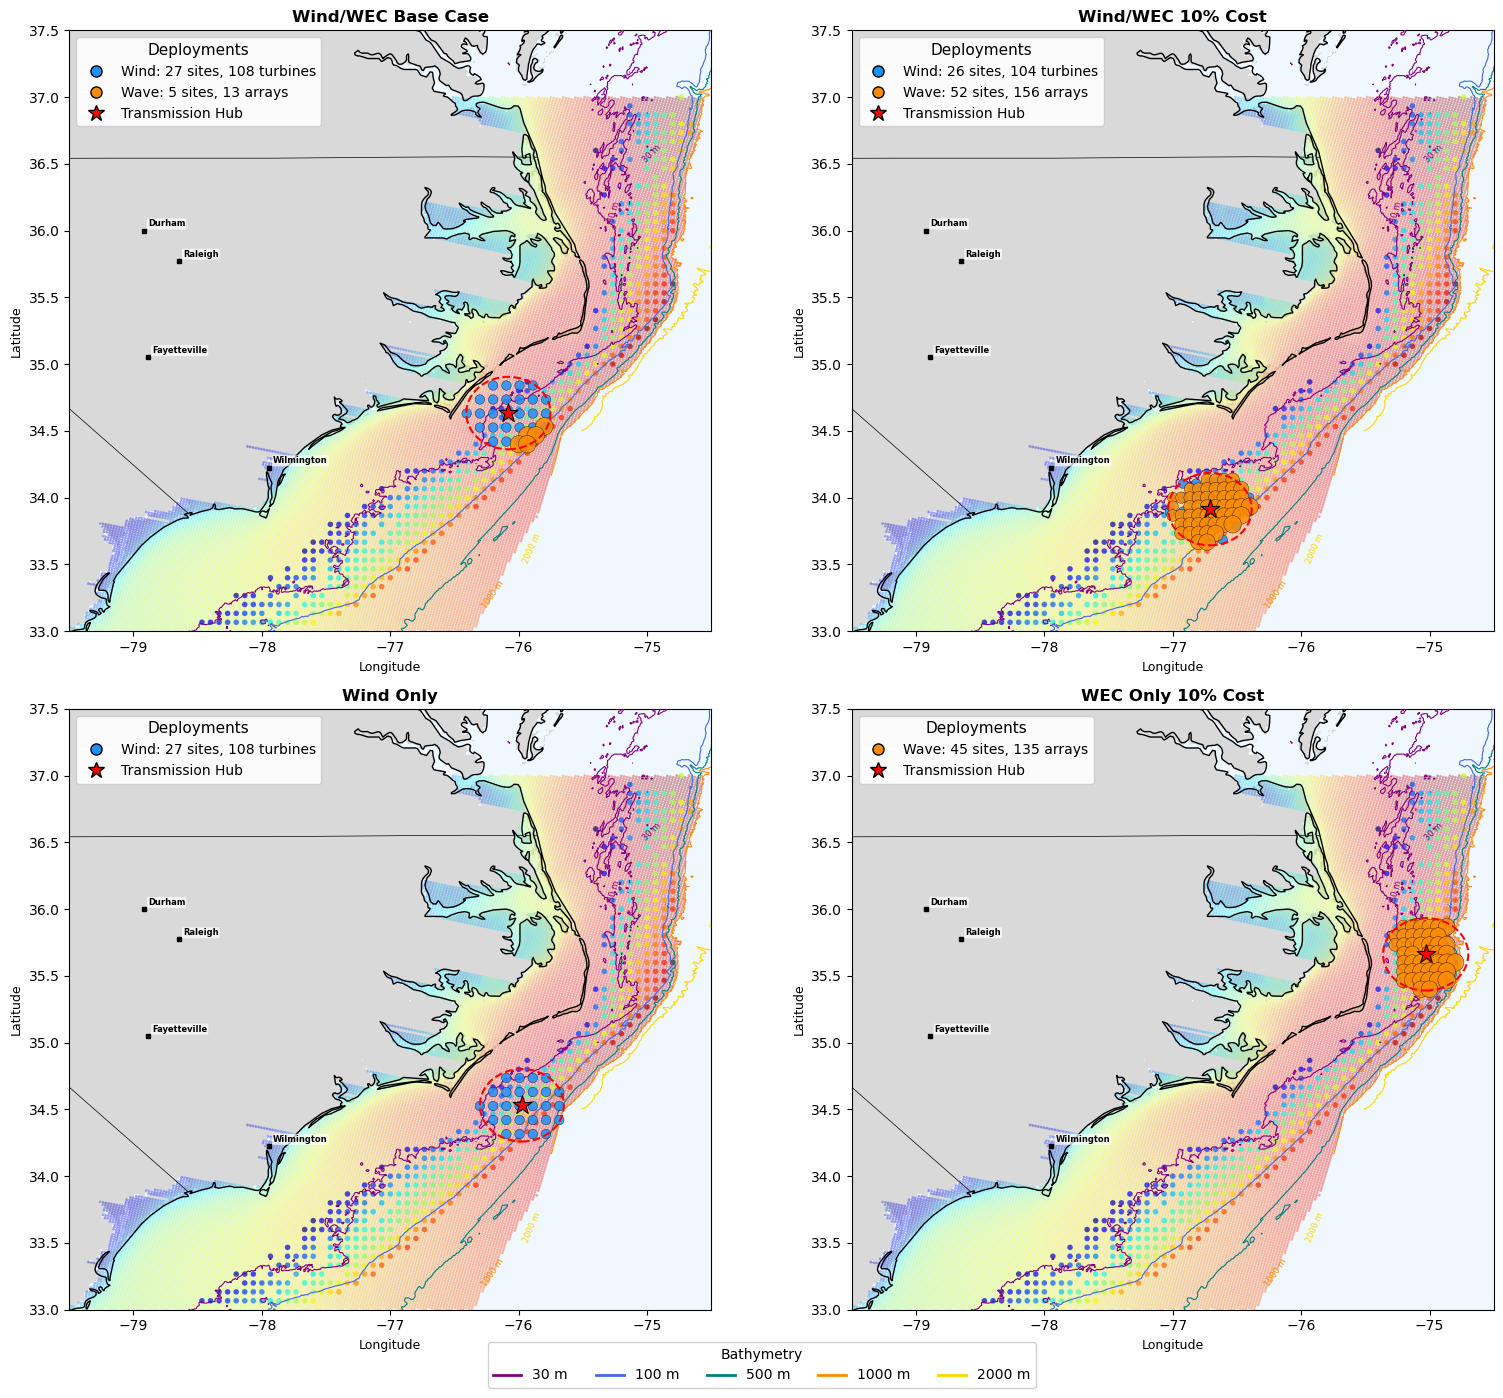

Done.


In [4]:
"""
Plot_Deployment_Over_Resource_NC.py
===================================
Fully self-contained. 2x2 grid of NC portfolio deployment maps with the raw
wind + wave resource underlaid (offshore scatter colored by value).

Deployed WAVE markers are SIZED by the standard deviation of the wave energy
flux at each selected site (same variability encoding as the resource map),
so high-variability vs low-variability siting is visible. Wind markers remain
sized by turbine count.

Layering (bottom -> top):
    land/ocean -> wind scatter -> wave flux scatter -> depth contours ->
    coast/borders -> deployment markers -> hub -> cities.

Notebook use: add %matplotlib inline at the top, then run this cell.
"""

import math
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xarray as xr
from matplotlib.lines import Line2D

# ======================================================================
# RESOURCE DATA SOURCES
# ======================================================================

WIND_RESOURCE_NPZ = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/Organize/Wind/Data_Wind/average_WS_140m.npz"
WAVE_RESOURCE_NPZ = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/InputData/Wave/WWIII_2005_2019.npz"

COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
PLACES_SHP  = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_populated_places.shp"

DEPTH_NC = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"

# ======================================================================
# SHARED TECH-DESIGN FILES
# ======================================================================

WIND_DESIGN  = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Wind/Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030.npz"
WAVE_DESIGN  = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Wave/2009_2013_HalfScale_63.62.npz"
TRANS_DESIGN = r"C:/Users/rmiller9/Desktop/OceanPortfolioOptimization/OutputData/Transmission/Transmission_1200MW.npz"

PORT = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios"

CASES = [
    {
        "title": "Wind/WEC Base Case",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz",
        "wind": [WIND_DESIGN], "wave": [WAVE_DESIGN], "kite": [], "trans": TRANS_DESIGN,
    },
    {
        "title": "Wind/WEC 10% Cost",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz",
        "wind": [WIND_DESIGN], "wave": [WAVE_DESIGN], "kite": [], "trans": TRANS_DESIGN,
    },
    {
        "title": "Wind Only",
        "portfolio": rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5\LCOE_120\Portfolio_LCOE_120.npz",
        "wind": [WIND_DESIGN], "wave": [], "kite": [], "trans": TRANS_DESIGN,
    },
    {
        "title": "WEC Only 10% Cost",
        "portfolio": rf"{PORT}\2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz",
        "wind": [], "wave": [WAVE_DESIGN], "kite": [], "trans": TRANS_DESIGN,
    },
]

# ======================================================================
# DISPLAY SETTINGS
# ======================================================================

XLIM = (-79.5, -74.5)
YLIM = (33.0, 37.5)

MAX_COLLECTION_RADIUS_KM = 30.0
WAVE_DEVICES_PER_ARRAY   = 100

# Resource underlay — same scatter approach + colormaps as the resource map
WIND_BG_CMAP  = "jet"
WIND_BG_S     = 4
WIND_BG_ALPHA = 0.35
WAVE_BG_CMAP  = "jet"
WAVE_BG_S     = 16
WAVE_BG_ALPHA = 0.70

# Deployed WAVE markers sized by resource-flux std (variability encoding).
# size = WAVE_STD_BASE + (std - std_min) * WAVE_STD_SCALE, clipped to [min,max]
WAVE_STD_BASE  = 15
WAVE_STD_SCALE = 15
WAVE_SIZE_MIN  = 15
WAVE_SIZE_MAX  = 160

TECH_COLORS = {"Wind": "dodgerblue", "Wave": "darkorange", "Kite": "limegreen"}

DEPTH_LEVELS = [30, 100, 500, 1000, 2000]
DEPTH_COLORS = {30: "purple", 100: "royalblue", 500: "teal", 1000: "darkorange", 2000: "gold"}

CITY_STATE   = "North Carolina"
CITY_POP_MIN = 100_000

SAVE_PATH = None

# ======================================================================
# HELPERS
# ======================================================================

def km_to_deg_lon(km, lat_deg):
    return km / (111.32 * np.cos(np.radians(lat_deg)))

def km_to_deg_lat(km):
    return km / 110.574

def _load_latlong_concat(design_paths):
    all_ll = []
    for p in design_paths:
        D = np.load(p, allow_pickle=True)
        all_ll.append(D["LatLong"])
        D.close()
    if len(all_ll) == 0:
        return np.empty((0, 2))
    return np.concatenate(all_ll, axis=0)

def _nearest_std(query_ll, ref_ll, ref_std):
    """For each query lat/lon, return the resource std of the nearest ref site."""
    out = np.empty(len(query_ll))
    for i, (qlat, qlon) in enumerate(query_ll):
        d2 = (ref_ll[:, 0] - qlat) ** 2 + (ref_ll[:, 1] - qlon) ** 2
        out[i] = ref_std[np.argmin(d2)]
    return out

# ======================================================================
# LOAD RESOURCE + GEO DATA (once)
# ======================================================================

print("Loading wind + wave resource and geo overlays …")

# --- Wind: offshore scatter points (NOT interpolated) ---
W = np.load(WIND_RESOURCE_NPZ)
wind_speed   = np.asarray(W["windspeed"], dtype=float)
wind_latlong = W["LatLong"]
wind_lon = wind_latlong[:, 1]
wind_lat = wind_latlong[:, 0]

# --- Wave energy flux mean + std (same computation + depth<200 filter) ---
Npz_Wave = np.load(WAVE_RESOURCE_NPZ, allow_pickle=True)
WaveLatLong = Npz_Wave["LatLong"]
Hsall = Npz_Wave["Hs"]
Tpall = Npz_Wave["Tp"]
WaveDepth = Npz_Wave["Depth"]
IdxIn = (WaveDepth < 200)
WaveLatLong = WaveLatLong[IdxIn, :]
Hsall = Hsall[IdxIn, :]
Tpall = Tpall[IdxIn, :]
rho, g = 1025.0, 9.81
wave_energy_flux = ((rho * g**2 * (Hsall**2) * (Tpall / 1.16)) / (64 * np.pi)) / 1e3  # kW/m
mean_wave_energy_flux = np.mean(wave_energy_flux, axis=1)
std_wave_energy_flux  = np.std(wave_energy_flux, axis=1)
wave_lon = WaveLatLong[:, 1]
wave_lat = WaveLatLong[:, 0]
STD_MIN_GLOBAL = std_wave_energy_flux.min()

# --- Depth grid for contours ---
ds      = xr.open_dataset(DEPTH_NC)
lat_d   = ds["lat"].values[::2]
lon_d   = ds["lon"].values[::2]
depth   = ds["depth"].values[::2, ::2]
LonGrid, LatGrid = np.meshgrid(lon_d, lat_d)
ds.close()

# --- Coast + borders + places ---
coast   = gpd.read_file(COAST_SHP)
borders = gpd.read_file(BORDERS_SHP)
places  = gpd.read_file(PLACES_SHP)
coast   = coast.set_crs(epsg=4326)   if coast.crs is None   else coast.to_crs(epsg=4326)
borders = borders.set_crs(epsg=4326) if borders.crs is None else borders.to_crs(epsg=4326)
places  = places.set_crs(epsg=4326)  if places.crs is None  else places.to_crs(epsg=4326)

places_sub = places.copy()
if CITY_STATE is not None and "ADM1NAME" in places_sub.columns:
    places_sub = places_sub[places_sub["ADM1NAME"] == CITY_STATE]
if CITY_POP_MIN is not None and "POP_MAX" in places_sub.columns:
    places_sub = places_sub[places_sub["POP_MAX"] >= CITY_POP_MIN]

# ======================================================================
# DRAW ONE CASE
# ======================================================================

def draw_case(ax, case):
    # --- Land/ocean background (bottom) ---
    ax.set_facecolor("#d9d9d9")  # grey land
    ax.contourf(LonGrid, LatGrid, depth,
                levels=[0, depth.max()], colors=["aliceblue"], zorder=0)

    # --- Resource underlay (offshore scatter) ---
    ax.scatter(wind_lon, wind_lat, c=wind_speed, cmap=WIND_BG_CMAP,
               s=WIND_BG_S, alpha=WIND_BG_ALPHA, edgecolors="none", zorder=1)
    ax.scatter(wave_lon, wave_lat, c=mean_wave_energy_flux, cmap=WAVE_BG_CMAP,
               s=WAVE_BG_S, alpha=WAVE_BG_ALPHA, edgecolors="none", zorder=2)

    # --- Depth contours (over the resource so they show) ---
    for lvl in DEPTH_LEVELS:
        cs = ax.contour(LonGrid, LatGrid, depth, levels=[lvl],
                        colors=[DEPTH_COLORS[lvl]], linewidths=0.8, zorder=3)
        ax.clabel(cs, inline=True, fontsize=6, fmt={lvl: f"{lvl} m"})

    # --- Coast + borders ---
    coast.plot(ax=ax, linewidth=1.0, color="black", zorder=4)
    borders.plot(ax=ax, linewidth=0.5, color="black", zorder=4)

    # --- Deployment data ---
    WindLatLong   = _load_latlong_concat(case["wind"])
    WaveLatLong_d = _load_latlong_concat(case["wave"])
    KiteLatLong   = _load_latlong_concat(case["kite"])

    TData        = np.load(case["trans"], allow_pickle=True)["TransmissionLineParameters"].item()
    TransLatLong = TData["TL_LatLong"]

    Z = np.load(case["portfolio"], allow_pickle=True)
    Y_Wind = Z["Y_Wind"] if "Y_Wind" in Z.files else np.empty((0,))
    Y_Wave = Z["Y_Wave"] if "Y_Wave" in Z.files else np.empty((0,))
    Y_Kite = Z["Y_Kite"] if "Y_Kite" in Z.files else np.empty((0,))
    s_arr  = Z["s_Transmission"]
    Z.close()

    legend_handles = []
    tech_data = [
        ("Wind", Y_Wind, WindLatLong),
        ("Wave", Y_Wave, WaveLatLong_d),
        ("Kite", Y_Kite, KiteLatLong),
    ]

    for tech_name, Y_arr, LatLong in tech_data:
        if len(Y_arr) == 0 or len(LatLong) == 0:
            continue
        active = np.where(Y_arr > 0.5)[0]
        if len(active) == 0:
            continue
        ll    = LatLong[active]
        units = Y_arr[active]
        color = TECH_COLORS.get(tech_name, "gray")

        if tech_name == "Wave":
            # size by resource-flux std at each selected site (variability encoding)
            site_std = _nearest_std(ll, WaveLatLong, std_wave_energy_flux)
            sizes = np.clip(WAVE_STD_BASE + (site_std - STD_MIN_GLOBAL) * WAVE_STD_SCALE,
                            WAVE_SIZE_MIN, WAVE_SIZE_MAX)
        else:
            # wind/kite sized by unit count (unchanged)
            sizes = np.clip(15 + units * 8, 15, 150)

        ax.scatter(ll[:, 1], ll[:, 0], s=sizes, c=color,
                   edgecolors="black", linewidths=0.3, alpha=0.85, zorder=5)

        n_sites = len(units)
        n_units = int(units.sum())
        if tech_name == "Wave":
            n_arrays = math.ceil(n_units / WAVE_DEVICES_PER_ARRAY)
            lbl = f"{tech_name}: {n_sites} sites, {n_arrays} arrays"
        else:
            lbl = f"{tech_name}: {n_sites} sites, {n_units} turbines"
        legend_handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
                   markeredgecolor="black", markersize=8, label=lbl)
        )

    # --- Transmission hub + collection radius ---
    hub_idx = np.argmax(s_arr)
    hub_ll  = TransLatLong[hub_idx]
    ax.scatter(hub_ll[1], hub_ll[0], s=200, c="red", marker="*",
               edgecolors="black", linewidths=0.8, zorder=6)
    legend_handles.append(
        Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
               markeredgecolor="black", markersize=12, label="Transmission Hub")
    )
    r_lat = km_to_deg_lat(MAX_COLLECTION_RADIUS_KM)
    r_lon = km_to_deg_lon(MAX_COLLECTION_RADIUS_KM, hub_ll[0])
    ax.add_patch(mpatches.Ellipse((hub_ll[1], hub_ll[0]),
                 width=2 * r_lon, height=2 * r_lat, fill=False,
                 edgecolor="red", linewidth=1.5, linestyle="--", zorder=6))

    # --- Populated places ---
    for _, row in places_sub.iterrows():
        lon = row.geometry.x
        lat = row.geometry.y
        if XLIM[0] <= lon <= XLIM[1] and YLIM[0] <= lat <= YLIM[1]:
            name = row.get("NAME", "")
            ax.plot(lon, lat, "s", color="black", markersize=3, zorder=7)
            ax.annotate(name, (lon, lat), fontsize=6, fontweight="bold",
                        xytext=(3, 3), textcoords="offset points", zorder=7,
                        color="black",
                        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.7))

    ax.set_xlim(XLIM)
    ax.set_ylim(YLIM)
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)
    ax.set_title(case["title"], fontsize=12, fontweight="bold")
    ax.legend(handles=legend_handles, loc="upper left", frameon=True,
              framealpha=0.9, facecolor="white", fontsize=10,
              title="Deployments", title_fontsize=11)

# ======================================================================
# BUILD 2x2 GRID (no colorbars, tight spacing)
# ======================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, case in zip(axes.flatten(), CASES):
    print(f"Drawing: {case['title']}")
    draw_case(ax, case)

depth_handles = [Line2D([0], [0], color=DEPTH_COLORS[l], lw=2, label=f"{l} m")
                 for l in DEPTH_LEVELS]
fig.legend(handles=depth_handles, loc="lower center", ncol=len(DEPTH_LEVELS),
           frameon=True, framealpha=0.9, facecolor="white",
           title="Bathymetry", bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.02, 1, 1])

if SAVE_PATH:
    fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
    print(f"Saved -> {SAVE_PATH}")

plt.show()
print("Done.")

In [5]:
print("design sites:", len(_load_latlong_concat([WAVE_DESIGN])))
print("resource sites (depth-filtered):", len(std_wave_energy_flux))

design sites: 380
resource sites (depth-filtered): 491


Efficient Frontier

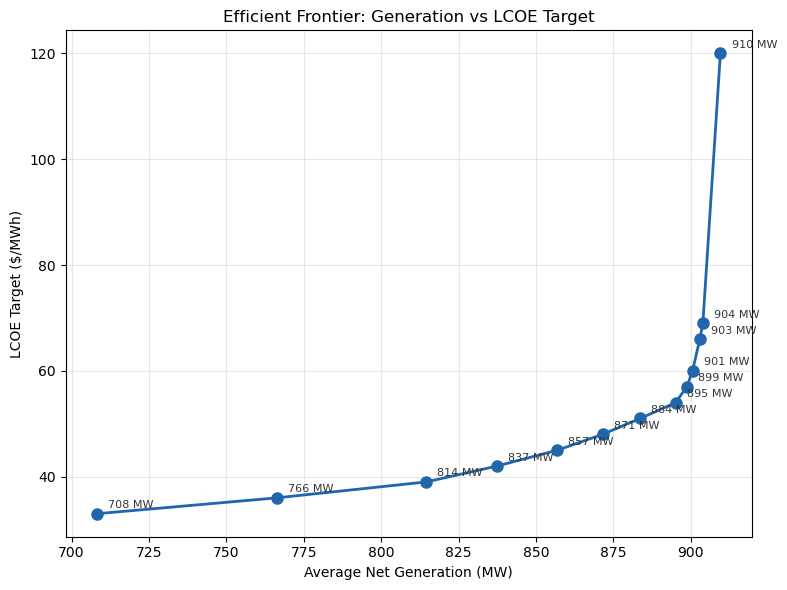

Done.


In [10]:
"""
Plot_EfficientFrontier_Standalone.py
=====================================
Reads Summary.csv from a portfolio run folder and plots the efficient frontier
with lowest LCOE at the bottom (intuitive orientation).

Usage:
    1. Set SUMMARY_CSV path below.
    2. Run:  python Plot_EfficientFrontier_Standalone.py
       — or paste into a Jupyter notebook (add %matplotlib inline at top).
"""

import pandas as pd
import matplotlib.pyplot as plt

# ======================================================================
# CONFIGURATION
# ======================================================================

SUMMARY_CSV = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\GenPU_ATB_18MW_2030_Florida_Florida_HalfScale_63.62_KitePower_Design3_Florida_100m_Transmission_1200MW_Florida\Summary.csv"

# Output — set to a folder path to save a PNG, or None to just display
SAVE_PATH = None  # e.g. r"C:\...\Plot_EfficientFrontier.png"

# ======================================================================
# LOAD DATA
# ======================================================================

df = pd.read_csv(SUMMARY_CSV)

# Handle both possible column name formats
lcoe_col = [c for c in df.columns if "LCOE_Target" in c][0]
mw_col   = [c for c in df.columns if "Total_MW_Avg" in c][0]

lcoe_targets = df[lcoe_col].values
mw_avgs      = df[mw_col].values

# ======================================================================
# PLOT
# ======================================================================

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mw_avgs, lcoe_targets, "o-", color="#2166ac", markersize=8, linewidth=2)

for x, y in zip(mw_avgs, lcoe_targets):
    ax.annotate(f"{x:.0f} MW", (x, y), textcoords="offset points",
                xytext=(8, 4), fontsize=8, color="#333333")

ax.set_xlabel("Average Net Generation (MW)")
ax.set_ylabel("LCOE Target ($/MWh)")
ax.set_title("Efficient Frontier: Generation vs LCOE Target")
ax.grid(True, alpha=0.3)

# NOTE: y-axis is NOT inverted — lowest LCOE is at the bottom
plt.tight_layout()

if SAVE_PATH:
    plt.savefig(SAVE_PATH, dpi=150, bbox_inches="tight")
    print(f"Saved → {SAVE_PATH}")

plt.show()
print("Done.")

Efficient Frontier with multiple scenarios

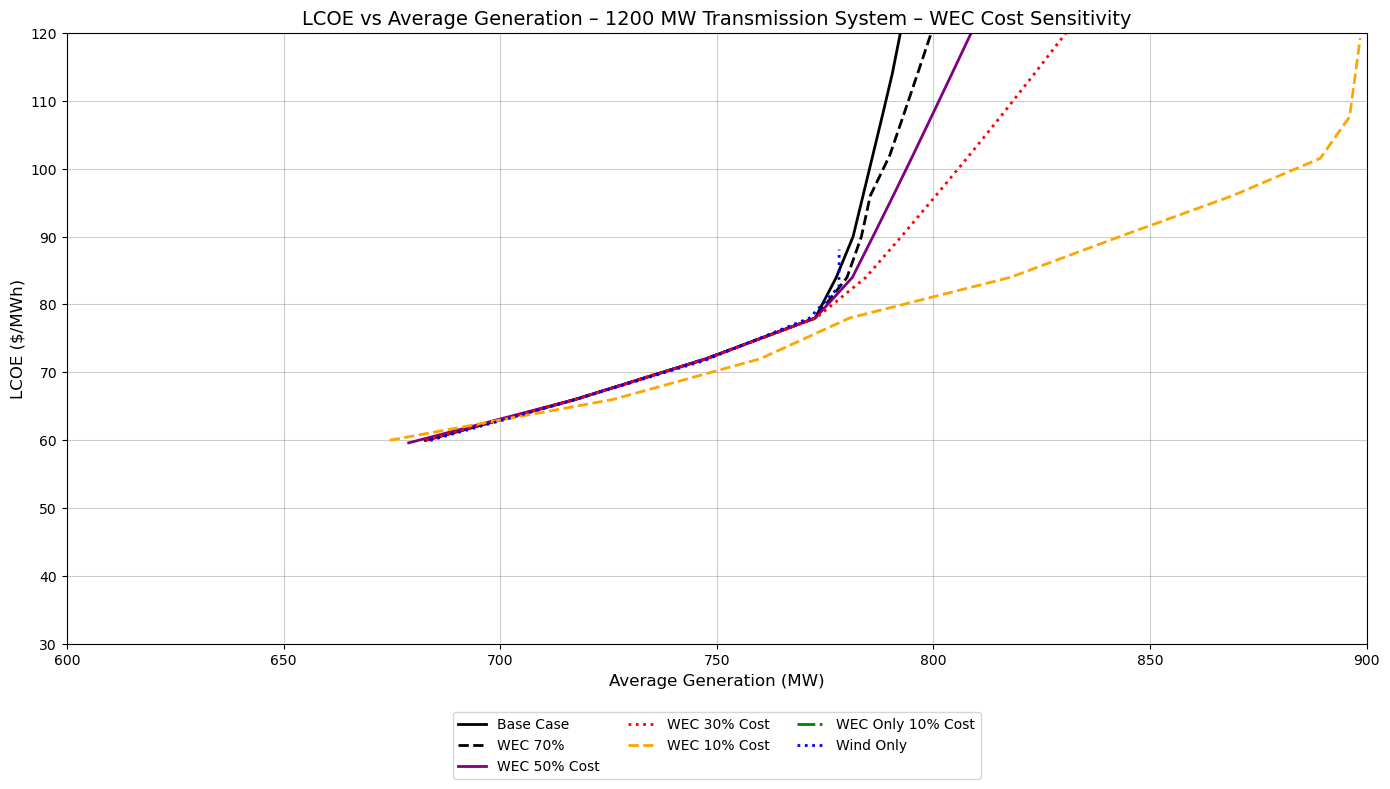

Done.


In [5]:
"""
Plot_EfficientFrontier_Multi.py
================================
Plots multiple efficient frontiers (LCOE vs average generation) on one graph,
one line per portfolio run. Built for the North Carolina WEC cost-sensitivity
set (baseline + forced-WEC + four reduced-cost cases), but works for any number
of runs — just add entries to RUNS.

Reads per-run .npz files containing:
    SaveTotalMWAvg      — average net generation (MW) at each LCOE step
    Save_LCOE_Achieved  — achieved LCOE ($/MWh) at each step

Usage:
    1. Fill in RUNS below (path, label, color, linestyle).
    2. Run:  python Plot_EfficientFrontier_Multi.py
       — or paste into a notebook (add %matplotlib inline at top).
"""

import numpy as np
import matplotlib.pyplot as plt

# ======================================================================
# CONFIGURATION
# ======================================================================

# Each run: (file_path, label, color, linestyle)
# Add or remove rows freely — the plot loop handles any count.
RUNS = [
    (r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\Combined_AllLCOE.npz",
     "Base Case",        "black",  "-"),
    (r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.7\Combined_AllLCOE.npz",
     "WEC 70%",     "black",  "--"),
    (r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.5\Combined_AllLCOE.npz",
     "WEC 50% Cost",    "purple", "-"),
    (r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.3\Combined_AllLCOE.npz",
     "WEC 30% Cost",     "red",    ":"),
    (r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\Combined_AllLCOE.npz",
     "WEC 10% Cost",     "orange", "--"),
    (r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\Combined_AllLCOE.npz",
     "WEC Only 10% Cost",     "green",  "-."),
    (r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5\Combined_AllLCOE.npz",
     "Wind Only",     "blue",   ":"),
]

# Axis limits
XLIM = (600, 900)
YLIM = (30, 120)

TITLE = "LCOE vs Average Generation – 1200 MW Transmission System – WEC Cost Sensitivity"

# Output — set to a path to save a PNG, or None to just display
SAVE_PATH = None  # e.g. r"C:\Users\rmiller9\Documents\East Coast Model\Plots\EfficientFrontier_NC.png"

# ======================================================================
# PLOT
# ======================================================================

def plot_frontiers(runs):
    plt.figure(figsize=(14, 8))

    for file_path, label, color, linestyle in runs:
        try:
            data = np.load(file_path, allow_pickle=True)
            MWAvg = np.array(data["SaveTotalMWAvg"], dtype=float)
            LCOE  = np.array(data["Save_LCOE_Achieved"], dtype=float)
        except Exception as e:
            print(f"Could not read {file_path}: {e}")
            continue

        # Drop NaNs
        mask = (~np.isnan(MWAvg)) & (~np.isnan(LCOE))
        MWAvg, LCOE = MWAvg[mask], LCOE[mask]

        if len(MWAvg) == 0:
            print(f"Empty or invalid data in {file_path}")
            continue

        # Sort by generation so the line draws left to right cleanly
        order = np.argsort(MWAvg)
        MWAvg, LCOE = MWAvg[order], LCOE[order]

        plt.plot(MWAvg, LCOE, label=label, color=color,
                 linestyle=linestyle, linewidth=2)

    plt.xlabel("Average Generation (MW)", fontsize=12)
    plt.ylabel("LCOE ($/MWh)", fontsize=12)
    plt.title(TITLE, fontsize=14)
    plt.xlim(*XLIM)
    plt.ylim(*YLIM)
    plt.grid(True, linestyle="-", color="gray", alpha=0.4)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1),
               ncol=3, fontsize=10)
    plt.tight_layout()

    if SAVE_PATH:
        plt.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
        print(f"Saved → {SAVE_PATH}")

    plt.show()
    print("Done.")


if __name__ == "__main__":
    plot_frontiers(RUNS)

In [17]:
import numpy as np
Z = np.load(r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz", allow_pickle=True)
print(Z.files)

['LCOE_Target', 'LCOE_Achieved', 'Total_MW_Avg', 'Wind_MW_Avg', 'Wave_MW_Avg', 'Kite_MW_Avg', 'Coaxial_MW_Avg', 'Tidal_MW_Avg', 'Curtailment_MW_Avg', 'Cost_Wind_MperYear', 'Cost_Wave_MperYear', 'Cost_Kite_MperYear', 'Cost_Coaxial_MperYear', 'Cost_Tidal_MperYear', 'Cost_Transmission_MperYear', 'Total_Cost_MperYear', 'Y_Wind', 'Y_Wave', 'Y_Kite', 'Y_Coaxial', 'Y_Tidal', 'W_Wind', 'W_Wave', 'W_Kite', 'W_Coaxial', 'W_Tidal', 's_Transmission', 'Delta', 'TimeSeries_Wind_MW', 'TimeSeries_Wave_MW', 'TimeSeries_Kite_MW', 'TimeSeries_Coaxial_MW', 'TimeSeries_Tidal_MW', 'TimeSeries_Curtailment_MW', 'TimeSeries_Total_MW', 'TimeList', 'Transmission_Capacity_MW']


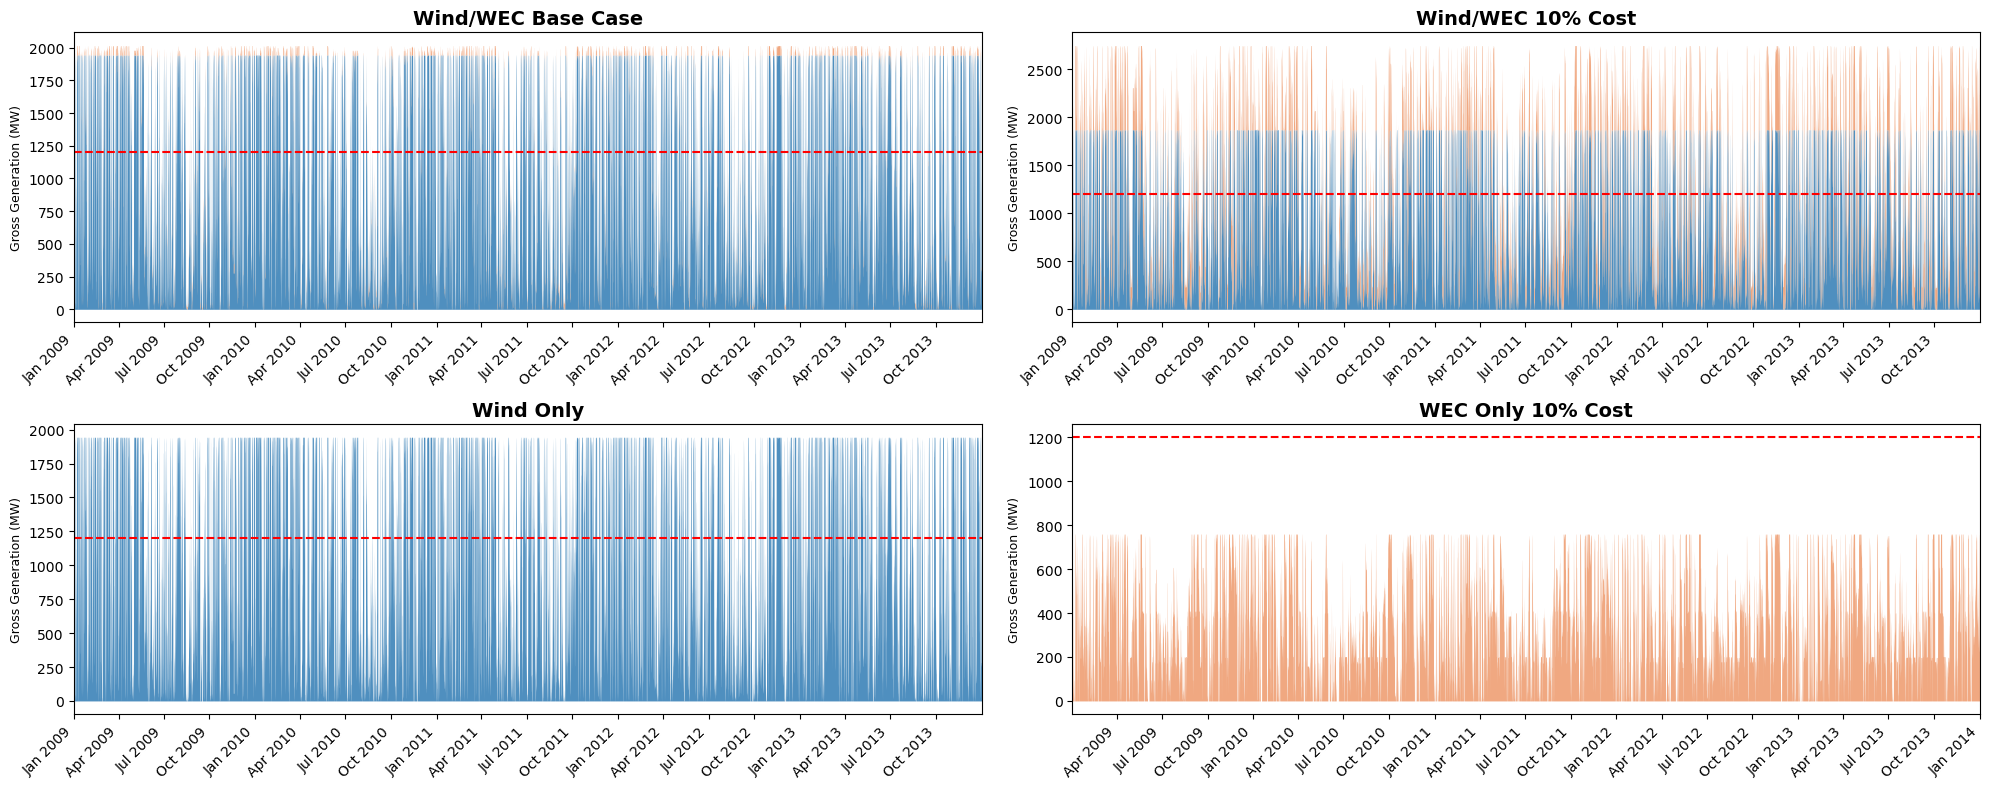

Done.


In [19]:
"""
Plot_Generation_Subplots_NC.py
==============================
2x2 grid of stacked Wind+Wave generation time series, one per scenario,
plotted directly from the portfolio .npz files (no saved PNGs, no baked-in
subtitle, vector-quality, tight spacing).

Each panel: stacked Wind (bottom) + Wave (top) gross generation over time,
with the transmission capacity line. Title is just the scenario name.

Notebook use: add %matplotlib inline at the top, then run this cell.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PORT = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios"

CASES = [
    ("Wind/WEC Base Case",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz"),
    ("Wind/WEC 10% Cost",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz"),
    ("Wind Only",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5\LCOE_120\Portfolio_LCOE_120.npz"),
    ("WEC Only 10% Cost",
     rf"{PORT}\2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz"),
]

WIND_COLOR = "#4F8FBF"   # matches the Wind blue
WAVE_COLOR = "#F0A881"   # matches the Wave orange
TRANS_COLOR = "red"

SAVE_PATH = None  # e.g. r"C:\...\Generation_2x2.png"

# ======================================================================
# PLOT
# ======================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 8), sharex=False)

for ax, (title, path) in zip(axes.flatten(), CASES):
    Z = np.load(path, allow_pickle=True)
    t    = np.asarray(Z["TimeList"])
    wind = np.asarray(Z["TimeSeries_Wind_MW"], dtype=float)
    wave = np.asarray(Z["TimeSeries_Wave_MW"], dtype=float)
    cap  = float(Z["Transmission_Capacity_MW"])
    Z.close()

    # Stack: wind on the bottom, wave on top
    ax.fill_between(t, 0, wind, color=WIND_COLOR, label="Wind", linewidth=0)
    ax.fill_between(t, wind, wind + wave, color=WAVE_COLOR, label="Wave", linewidth=0)
    ax.axhline(cap, color=TRANS_COLOR, linestyle="--", linewidth=1.5,
               label=f"Transmission Capacity ({cap:.0f} MW)")

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel("Gross Generation (MW)", fontsize=9)
    #ax.set_xlabel("Time", fontsize=9)
    #ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    ax.margins(x=0)

    # Clean date ticks
    try:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(45)
            lbl.set_ha("right")
    except Exception:
        pass

plt.tight_layout()
plt.subplots_adjust(hspace=0.35, wspace=0.10)

if SAVE_PATH:
    fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
    print(f"Saved -> {SAVE_PATH}")

plt.show()
print("Done.")

Generation variability


=== Generation Variability Metrics (all at LCOE_120) ===

                    Mean Gen (MW)  Overall CV  Seasonal CV  Annual CV  Ramp Std (MW)  % Hours < 10% Cap
Scenario                                                                                               
Wind/WEC Base Case        792.369       0.568        0.136      0.024        200.640             11.487
Wind/WEC 10% Cost         898.381       0.422        0.085      0.023        165.733              2.861
Wind Only                 778.255       0.593        0.145      0.022        203.148             13.650
WEC Only 10% Cost         352.950       0.672        0.210      0.227         81.334             18.339

Saved table -> C:\Users\rmiller9\Documents\East Coast Model\Variability_Metrics.csv


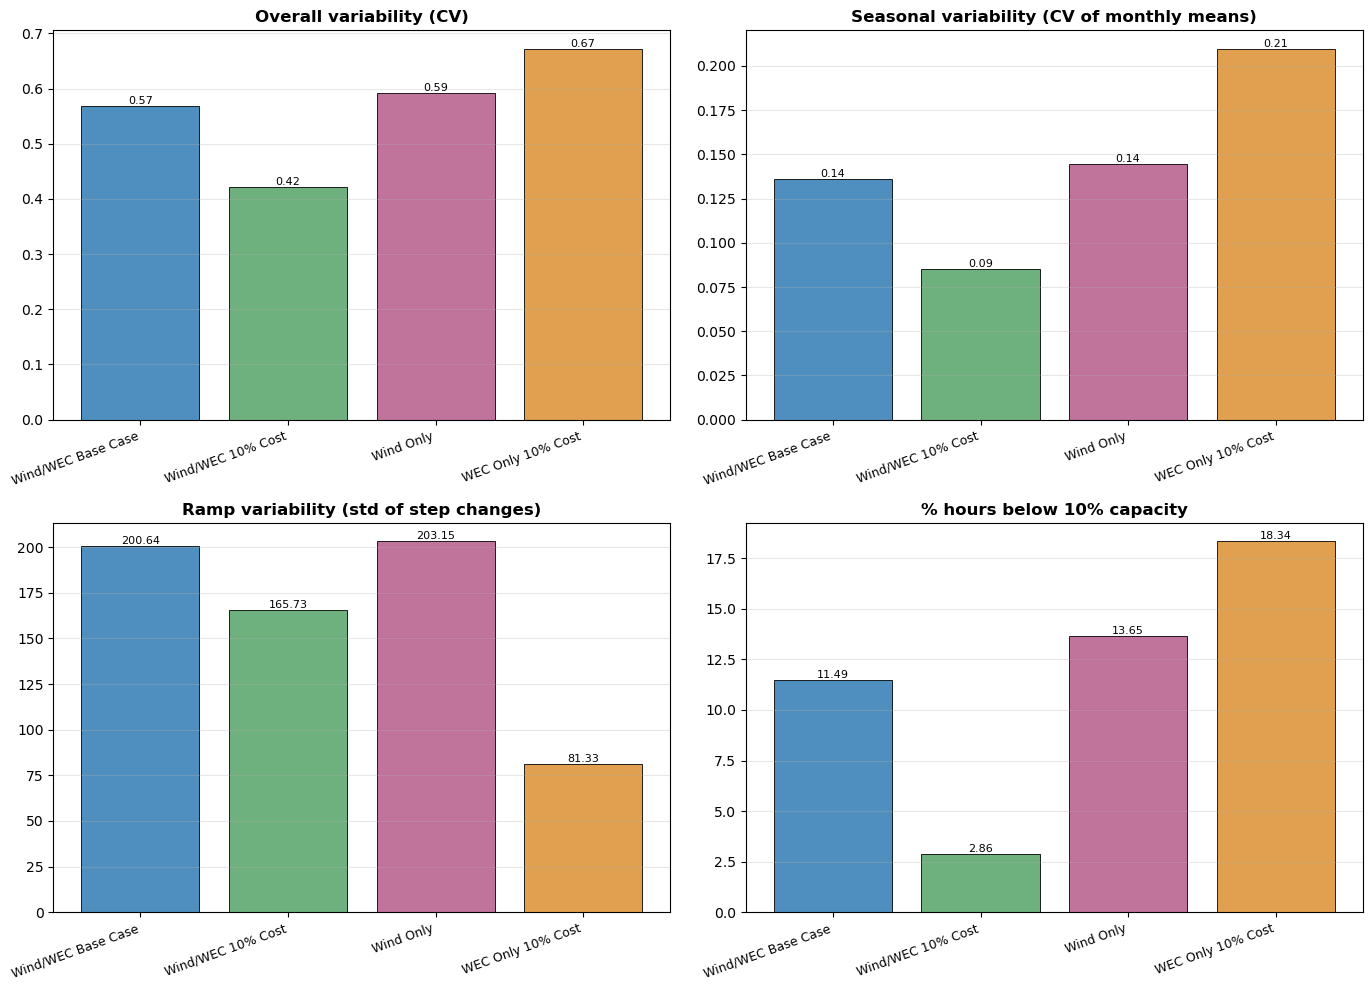

Done.


In [20]:
"""
Generation_Variability_Metrics.py
=================================
Quantifies how WECs smooth generation across scenarios using the portfolio
.npz time series. Computes, per scenario:

    - Overall CV         = std(total) / mean(total)            [unitless]
    - Seasonal CV        = std(monthly climatology) / mean      [unitless]
    - Annual CV          = std(annual means) / mean             [unitless]
    - Ramp std           = std of timestep-to-timestep change   [MW]
    - % low-output hours = % of timesteps below 10% of capacity [%]

Outputs a printed table, a CSV, and a 2x2 bar chart.

NOTE: compare scenarios at the same LCOE budget (these are all LCOE_120) so
the smoothing isn't confounded by different generation levels.

Notebook use: add %matplotlib inline at the top, then run this cell.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PORT = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios"

CASES = [
    ("Wind/WEC Base Case",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz"),
    ("Wind/WEC 10% Cost",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz"),
    ("Wind Only",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5\LCOE_120\Portfolio_LCOE_120.npz"),
    ("WEC Only 10% Cost",
     rf"{PORT}\2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz"),
]

LOW_OUTPUT_FRACTION = 0.10   # threshold for "low-output" hours (of transmission capacity)
SAVE_CSV = r"C:\Users\rmiller9\Documents\East Coast Model\Variability_Metrics.csv"
SAVE_FIG = None              # e.g. r"C:\...\Variability_Metrics.png"

# ======================================================================
# COMPUTE METRICS
# ======================================================================

rows = []
for title, path in CASES:
    Z = np.load(path, allow_pickle=True)
    total = np.asarray(Z["TimeSeries_Total_MW"], dtype=float)
    tlist = np.asarray(Z["TimeList"])
    cap   = float(Z["Transmission_Capacity_MW"])
    Z.close()

    # Build a datetime index (robust to datetime objects or strings)
    try:
        idx = pd.to_datetime(tlist)
    except Exception:
        idx = pd.RangeIndex(len(total))  # fallback: positional

    s = pd.Series(total, index=idx)
    mean_gen = s.mean()

    # Overall CV
    overall_cv = s.std() / mean_gen if mean_gen else np.nan

    # Seasonal CV: climatological monthly means (Jan..Dec averaged over years)
    if isinstance(idx, pd.DatetimeIndex):
        monthly_clim = s.groupby(s.index.month).mean()
        seasonal_cv = monthly_clim.std() / mean_gen if mean_gen else np.nan
        annual_means = s.groupby(s.index.year).mean()
        annual_cv = annual_means.std() / mean_gen if mean_gen else np.nan
    else:
        seasonal_cv = np.nan
        annual_cv = np.nan

    # Ramp std: timestep-to-timestep change
    ramp_std = np.std(np.diff(total))

    # % low-output timesteps
    thresh = LOW_OUTPUT_FRACTION * cap
    pct_low = 100.0 * np.mean(total < thresh)

    rows.append({
        "Scenario": title,
        "Mean Gen (MW)": mean_gen,
        "Overall CV": overall_cv,
        "Seasonal CV": seasonal_cv,
        "Annual CV": annual_cv,
        "Ramp Std (MW)": ramp_std,
        f"% Hours < {int(LOW_OUTPUT_FRACTION*100)}% Cap": pct_low,
    })

df = pd.DataFrame(rows).set_index("Scenario")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print("\n=== Generation Variability Metrics (all at LCOE_120) ===\n")
print(df.to_string())

if SAVE_CSV:
    df.to_csv(SAVE_CSV)
    print(f"\nSaved table -> {SAVE_CSV}")

# ======================================================================
# BAR CHARTS (one metric per panel — different scales)
# ======================================================================

metrics_to_plot = [
    ("Overall CV", "Overall variability (CV)"),
    ("Seasonal CV", "Seasonal variability (CV of monthly means)"),
    ("Ramp Std (MW)", "Ramp variability (std of step changes)"),
    (f"% Hours < {int(LOW_OUTPUT_FRACTION*100)}% Cap", f"% hours below {int(LOW_OUTPUT_FRACTION*100)}% capacity"),
]

colors = ["#4F8FBF", "#6FB07F", "#C0739B", "#E0A04F"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, label) in zip(axes.flatten(), metrics_to_plot):
    vals = df[col].values
    ax.bar(range(len(df)), vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df.index, rotation=20, ha="right", fontsize=9)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    # value labels on bars
    for i, v in enumerate(vals):
        if np.isfinite(v):
            ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

if SAVE_FIG:
    fig.savefig(SAVE_FIG, dpi=200, bbox_inches="tight")
    print(f"Saved figure -> {SAVE_FIG}")

plt.show()
print("Done.")

Seasonal Variability (Quarterly)


=== Generation Variability Metrics (all at LCOE_120) ===

                    Mean Gen (MW)  Overall CV (%)  Seasonal CV (%)  Annual CV  Ramp Std (MW)  % Hours < 10% Cap
Scenario                                                                                                       
Wind/WEC Base Case        792.369          56.847           13.600      0.024        200.640             11.487
Wind/WEC 10% Cost         898.381          42.184            8.512      0.023        165.733              2.861
Wind Only                 778.255          59.260           14.474      0.022        203.148             13.650
WEC Only 10% Cost         352.950          67.181           20.967      0.227         81.334             18.339

Saved table -> C:\Users\rmiller9\Documents\East Coast Model\Variability_Metrics.csv


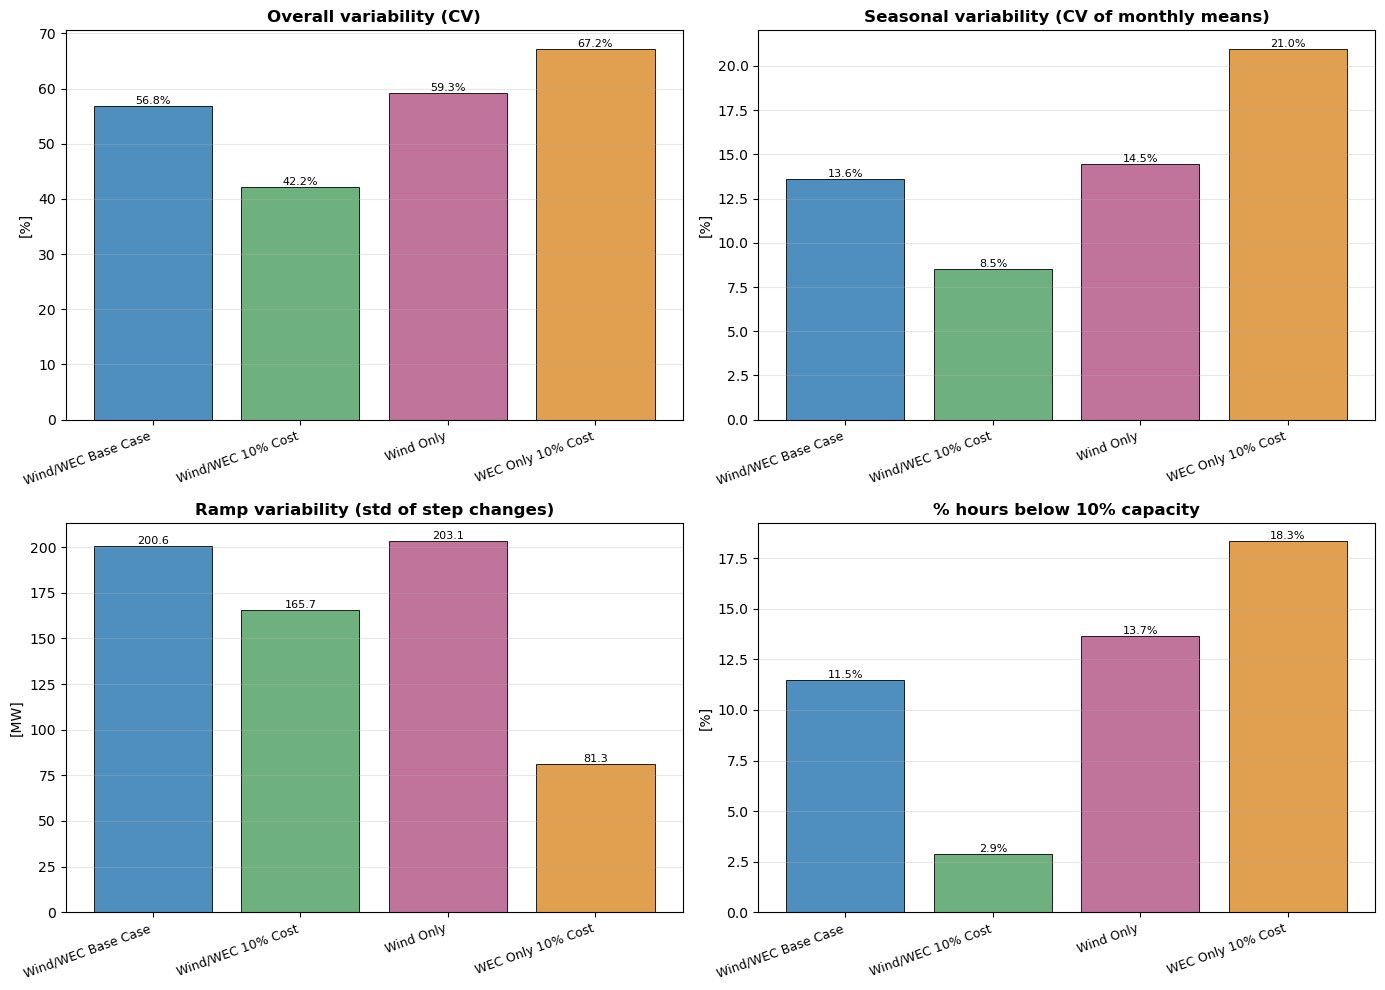


=== Seasonal (3-month quarter) Variability ===

                    Seasonal CV (3mo) (%)  DJF Mean (MW)  MAM Mean (MW)  JJA Mean (MW)  SON Mean (MW)
Scenario                                                                                             
Wind/WEC Base Case                 10.116        875.505        843.034        703.711        748.374
Wind/WEC 10% Cost                   6.926        952.580        938.341        814.786        888.775
Wind Only                          10.856        868.835        828.192        686.019        731.236
WEC Only 10% Cost                  19.492        360.070        386.537        254.807        411.158


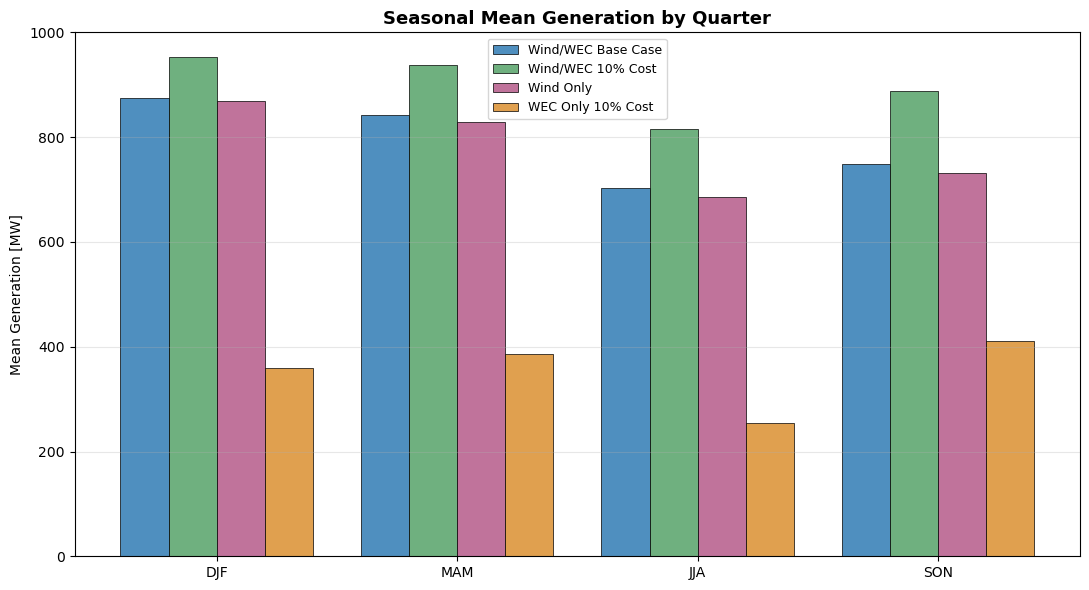

Done.


In [1]:
"""
Generation_Variability_Metrics.py
=================================
Quantifies how WECs smooth generation across scenarios using the portfolio
.npz time series. Computes, per scenario:

    - Overall CV         = std(total) / mean(total)            [shown as %]
    - Seasonal CV        = std(monthly climatology) / mean      [shown as %]
    - Annual CV          = std(annual means) / mean             [unitless]
    - Ramp std           = std of timestep-to-timestep change   [MW]
    - % low-output hours = % of timesteps below 10% of capacity [%]

Also includes a SEPARATE block computing seasonal variability by 3-month
meteorological quarters (DJF, MAM, JJA, SON).

Notebook use: add %matplotlib inline at the top, then run this cell.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PORT = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios"

CASES = [
    ("Wind/WEC Base Case",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz"),
    ("Wind/WEC 10% Cost",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz"),
    ("Wind Only",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5\LCOE_120\Portfolio_LCOE_120.npz"),
    ("WEC Only 10% Cost",
     rf"{PORT}\2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz"),
]

LOW_OUTPUT_FRACTION = 0.10
SAVE_CSV = r"C:\Users\rmiller9\Documents\East Coast Model\Variability_Metrics.csv"
SAVE_FIG = None

# ======================================================================
# COMPUTE METRICS
# ======================================================================

rows = []
for title, path in CASES:
    Z = np.load(path, allow_pickle=True)
    total = np.asarray(Z["TimeSeries_Total_MW"], dtype=float)
    tlist = np.asarray(Z["TimeList"])
    cap   = float(Z["Transmission_Capacity_MW"])
    Z.close()

    try:
        idx = pd.to_datetime(tlist)
    except Exception:
        idx = pd.RangeIndex(len(total))

    s = pd.Series(total, index=idx)
    mean_gen = s.mean()
    overall_cv = s.std() / mean_gen if mean_gen else np.nan

    if isinstance(idx, pd.DatetimeIndex):
        monthly_clim = s.groupby(s.index.month).mean()
        seasonal_cv = monthly_clim.std() / mean_gen if mean_gen else np.nan
        annual_means = s.groupby(s.index.year).mean()
        annual_cv = annual_means.std() / mean_gen if mean_gen else np.nan
    else:
        seasonal_cv = annual_cv = np.nan

    ramp_std = np.std(np.diff(total))
    thresh = LOW_OUTPUT_FRACTION * cap
    pct_low = 100.0 * np.mean(total < thresh)

    rows.append({
        "Scenario": title,
        "Mean Gen (MW)": mean_gen,
        "Overall CV (%)": overall_cv * 100,
        "Seasonal CV (%)": seasonal_cv * 100,
        "Annual CV": annual_cv,
        "Ramp Std (MW)": ramp_std,
        f"% Hours < {int(LOW_OUTPUT_FRACTION*100)}% Cap": pct_low,
    })

df = pd.DataFrame(rows).set_index("Scenario")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print("\n=== Generation Variability Metrics (all at LCOE_120) ===\n")
print(df.to_string())
if SAVE_CSV:
    df.to_csv(SAVE_CSV)
    print(f"\nSaved table -> {SAVE_CSV}")

# ======================================================================
# BAR CHARTS — CV panels in %, ramp in MW, all labels 1 decimal
# ======================================================================

PCT_COL = f"% Hours < {int(LOW_OUTPUT_FRACTION*100)}% Cap"
metrics_to_plot = [
    ("Overall CV (%)",  "Overall variability (CV)",                 "%"),
    ("Seasonal CV (%)", "Seasonal variability (CV of monthly means)", "%"),
    ("Ramp Std (MW)",   "Ramp variability (std of step changes)",    "MW"),
    (PCT_COL,           "% hours below 10% capacity",                "%"),
]

colors = ["#4F8FBF", "#6FB07F", "#C0739B", "#E0A04F"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, label, unit) in zip(axes.flatten(), metrics_to_plot):
    vals = df[col].values
    ax.bar(range(len(df)), vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df.index, rotation=20, ha="right", fontsize=9)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylabel(f"[{unit}]", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        if np.isfinite(v):
            suffix = "%" if unit == "%" else ""
            ax.text(i, v, f"{v:.1f}{suffix}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
if SAVE_FIG:
    fig.savefig(SAVE_FIG, dpi=200, bbox_inches="tight")
    print(f"Saved figure -> {SAVE_FIG}")
plt.show()

# ======================================================================
# SEPARATE BLOCK: seasonal variability by 3-month quarters (DJF/MAM/JJA/SON)
# ======================================================================

print("\n=== Seasonal (3-month quarter) Variability ===\n")

# meteorological season map
SEASON = {12: "DJF", 1: "DJF", 2: "DJF",
          3: "MAM", 4: "MAM", 5: "MAM",
          6: "JJA", 7: "JJA", 8: "JJA",
          9: "SON", 10: "SON", 11: "SON"}
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]

season_rows = []
season_means_by_scenario = {}
for title, path in CASES:
    Z = np.load(path, allow_pickle=True)
    total = np.asarray(Z["TimeSeries_Total_MW"], dtype=float)
    tlist = np.asarray(Z["TimeList"])
    Z.close()
    try:
        idx = pd.to_datetime(tlist)
    except Exception:
        print(f"{title}: non-datetime TimeList, skipping seasonal quarter calc")
        continue

    s = pd.Series(total, index=idx)
    mean_gen = s.mean()
    season_label = s.index.month.map(SEASON)
    season_means = s.groupby(season_label).mean().reindex(SEASON_ORDER)
    season_means_by_scenario[title] = season_means

    # quarterly seasonal CV: std of the 4 seasonal means / overall mean
    q_seasonal_cv = season_means.std() / mean_gen if mean_gen else np.nan

    row = {"Scenario": title, "Seasonal CV (3mo) (%)": q_seasonal_cv * 100}
    for seas in SEASON_ORDER:
        row[f"{seas} Mean (MW)"] = season_means[seas]
    season_rows.append(row)

season_df = pd.DataFrame(season_rows).set_index("Scenario")
print(season_df.to_string())

# Grouped bar: seasonal mean generation by quarter, one group per scenario
if season_means_by_scenario:
    fig2, ax2 = plt.subplots(figsize=(11, 6))
    n_scen = len(season_means_by_scenario)
    x = np.arange(len(SEASON_ORDER))
    width = 0.8 / n_scen
    for k, (title, sm) in enumerate(season_means_by_scenario.items()):
        ax2.bar(x + k * width, sm.values, width, label=title,
                color=colors[k % len(colors)], edgecolor="black", linewidth=0.5)
    ax2.set_xticks(x + width * (n_scen - 1) / 2)
    ax2.set_xticklabels(SEASON_ORDER)
    ax2.set_ylabel("Mean Generation [MW]")
    ax2.set_title("Seasonal Mean Generation by Quarter", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=9)
    ax2.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Done.")


=== Generation Variability Metrics (all at LCOE_120) ===

                    Mean Gen (MW)  Overall CV (%)  Seasonal CV 3mo (%)  Annual CV  Ramp Std (MW)  % Hours < 10% Cap
Scenario                                                                                                           
Wind/WEC Base Case        792.369          56.847               10.116      0.024        200.640             11.487
Wind/WEC 10% Cost         898.381          42.184                6.926      0.023        165.733              2.861
Wind Only                 778.255          59.260               10.856      0.022        203.148             13.650
WEC Only 10% Cost         352.950          67.181               19.492      0.227         81.334             18.339

Saved table -> C:\Users\rmiller9\Documents\East Coast Model\Variability_Metrics.csv


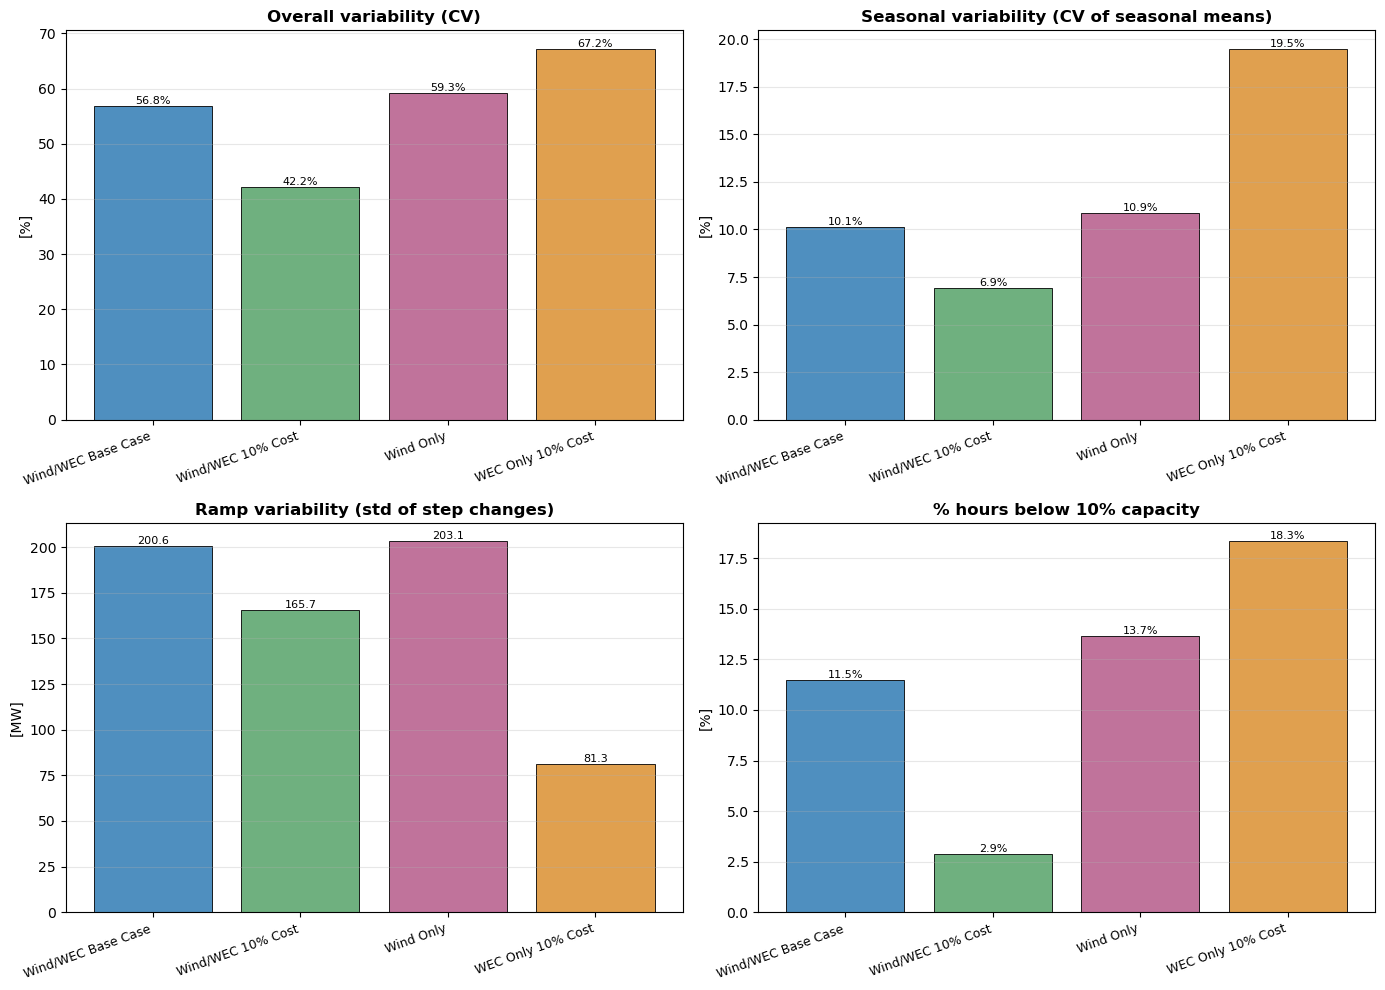

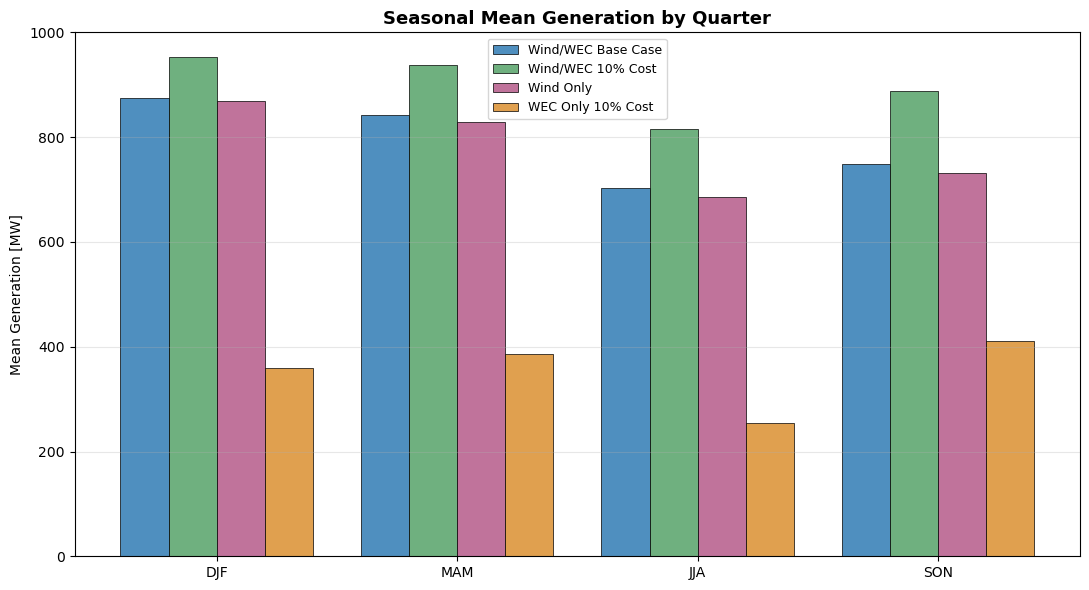

Done.


In [2]:
"""
Generation_Variability_Metrics.py
=================================
Quantifies how WECs smooth generation across scenarios using the portfolio
.npz time series. Computes, per scenario:

    - Overall CV          = std(total) / mean(total)             [shown as %]
    - Seasonal CV (3mo)   = std(DJF/MAM/JJA/SON means) / mean    [shown as %]
    - Annual CV           = std(annual means) / mean             [unitless]
    - Ramp std            = std of timestep-to-timestep change   [MW]
    - % low-output hours  = % of timesteps below 10% of capacity [%]

The 2x2 bar chart shows Overall CV (%), Seasonal CV 3mo (%), Ramp Std (MW),
and % hours below 10% capacity.

Notebook use: add %matplotlib inline at the top, then run this cell.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PORT = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios"

CASES = [
    ("Wind/WEC Base Case",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\LCOE_120\Portfolio_LCOE_120.npz"),
    ("Wind/WEC 10% Cost",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz"),
    ("Wind Only",
     rf"{PORT}\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5\LCOE_120\Portfolio_LCOE_120.npz"),
    ("WEC Only 10% Cost",
     rf"{PORT}\2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1\LCOE_120\Portfolio_LCOE_120.npz"),
]

LOW_OUTPUT_FRACTION = 0.10
SAVE_CSV = r"C:\Users\rmiller9\Documents\East Coast Model\Variability_Metrics.csv"
SAVE_FIG = None

# 3-month meteorological seasons
SEASON = {12: "DJF", 1: "DJF", 2: "DJF",
          3: "MAM", 4: "MAM", 5: "MAM",
          6: "JJA", 7: "JJA", 8: "JJA",
          9: "SON", 10: "SON", 11: "SON"}
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]

# ======================================================================
# COMPUTE METRICS
# ======================================================================

rows = []
season_means_by_scenario = {}

for title, path in CASES:
    Z = np.load(path, allow_pickle=True)
    total = np.asarray(Z["TimeSeries_Total_MW"], dtype=float)
    tlist = np.asarray(Z["TimeList"])
    cap   = float(Z["Transmission_Capacity_MW"])
    Z.close()

    try:
        idx = pd.to_datetime(tlist)
    except Exception:
        idx = pd.RangeIndex(len(total))

    s = pd.Series(total, index=idx)
    mean_gen = s.mean()
    overall_cv = s.std() / mean_gen if mean_gen else np.nan

    if isinstance(idx, pd.DatetimeIndex):
        # 3-month seasonal means -> quarterly seasonal CV
        season_means = s.groupby(s.index.month.map(SEASON)).mean().reindex(SEASON_ORDER)
        seasonal_cv_q = season_means.std() / mean_gen if mean_gen else np.nan
        season_means_by_scenario[title] = season_means
        # annual
        annual_means = s.groupby(s.index.year).mean()
        annual_cv = annual_means.std() / mean_gen if mean_gen else np.nan
    else:
        seasonal_cv_q = annual_cv = np.nan

    ramp_std = np.std(np.diff(total))
    thresh = LOW_OUTPUT_FRACTION * cap
    pct_low = 100.0 * np.mean(total < thresh)

    rows.append({
        "Scenario": title,
        "Mean Gen (MW)": mean_gen,
        "Overall CV (%)": overall_cv * 100,
        "Seasonal CV 3mo (%)": seasonal_cv_q * 100,
        "Annual CV": annual_cv,
        "Ramp Std (MW)": ramp_std,
        f"% Hours < {int(LOW_OUTPUT_FRACTION*100)}% Cap": pct_low,
    })

df = pd.DataFrame(rows).set_index("Scenario")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print("\n=== Generation Variability Metrics (all at LCOE_120) ===\n")
print(df.to_string())
if SAVE_CSV:
    df.to_csv(SAVE_CSV)
    print(f"\nSaved table -> {SAVE_CSV}")

# ======================================================================
# 2x2 BAR CHART — CV panels in %, ramp in MW, labels to 1 decimal
# ======================================================================

PCT_COL = f"% Hours < {int(LOW_OUTPUT_FRACTION*100)}% Cap"
metrics_to_plot = [
    ("Overall CV (%)",      "Overall variability (CV)",                    "%"),
    ("Seasonal CV 3mo (%)", "Seasonal variability (CV of seasonal means)", "%"),
    ("Ramp Std (MW)",       "Ramp variability (std of step changes)",      "MW"),
    (PCT_COL,               "% hours below 10% capacity",                  "%"),
]

colors = ["#4F8FBF", "#6FB07F", "#C0739B", "#E0A04F"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, label, unit) in zip(axes.flatten(), metrics_to_plot):
    vals = df[col].values
    ax.bar(range(len(df)), vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df.index, rotation=20, ha="right", fontsize=9)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylabel(f"[{unit}]", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        if np.isfinite(v):
            suffix = "%" if unit == "%" else ""
            ax.text(i, v, f"{v:.1f}{suffix}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
if SAVE_FIG:
    fig.savefig(SAVE_FIG, dpi=200, bbox_inches="tight")
    print(f"Saved figure -> {SAVE_FIG}")
plt.show()

# ======================================================================
# Optional: grouped seasonal-mean-generation bar chart (by quarter)
# ======================================================================

if season_means_by_scenario:
    fig2, ax2 = plt.subplots(figsize=(11, 6))
    n_scen = len(season_means_by_scenario)
    x = np.arange(len(SEASON_ORDER))
    width = 0.8 / n_scen
    for k, (title, sm) in enumerate(season_means_by_scenario.items()):
        ax2.bar(x + k * width, sm.values, width, label=title,
                color=colors[k % len(colors)], edgecolor="black", linewidth=0.5)
    ax2.set_xticks(x + width * (n_scen - 1) / 2)
    ax2.set_xticklabels(SEASON_ORDER)
    ax2.set_ylabel("Mean Generation [MW]")
    ax2.set_title("Seasonal Mean Generation by Quarter", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=9)
    ax2.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Done.")

In [21]:
import numpy as np
Z = np.load(r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios\Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW\Combined_AllLCOE.npz", allow_pickle=True)
print(Z.files)

['ReadMe', 'PathWindDesigns', 'PathWaveDesigns', 'PathKiteDesigns', 'PathCoaxialDesigns', 'PathTidalDesigns', 'PathTransmissionDesign', 'LCOE_RANGE', 'Max_CollectionRadious', 'MaxDesignsWind', 'MaxDesingsWave', 'MaxDesingsKite', 'MaxDesignsCoaxial', 'MaxDesignsTidal', 'MinNumWindTurb', 'MinNumWaveTurb', 'MinNumKiteTrub', 'MinNumCoaxialTurb', 'MinNumTidalTurb', 'SaveFeasibility', 'Save_LCOETarget', 'Save_LCOE_Achieved', 'SaveTotalMWAvg', 'Save_TotalMWAvgWind', 'Save_TotalMWAvgWave', 'Save_TotalMWAvgKite', 'Save_TotalMWAvgCoaxial', 'Save_TotalMWAvgTidal', 'Save_totalMWAvgCurtailment', 'Save_CostWind', 'Save_CostWave', 'Save_CostKite', 'Save_CostCoaxial', 'Save_CostTidal', 'Save_CostTransmission', 'Save_Y_Wind', 'Save_Y_Wave', 'Save_Y_Kite', 'Save_Y_Coaxial', 'Save_Y_Tidal', 'Save_W_Wind', 'Save_W_Wave', 'Save_W_Kite', 'Save_W_Coaxial', 'Save_W_Tidal', 'Save_s', 'Save_Delta']


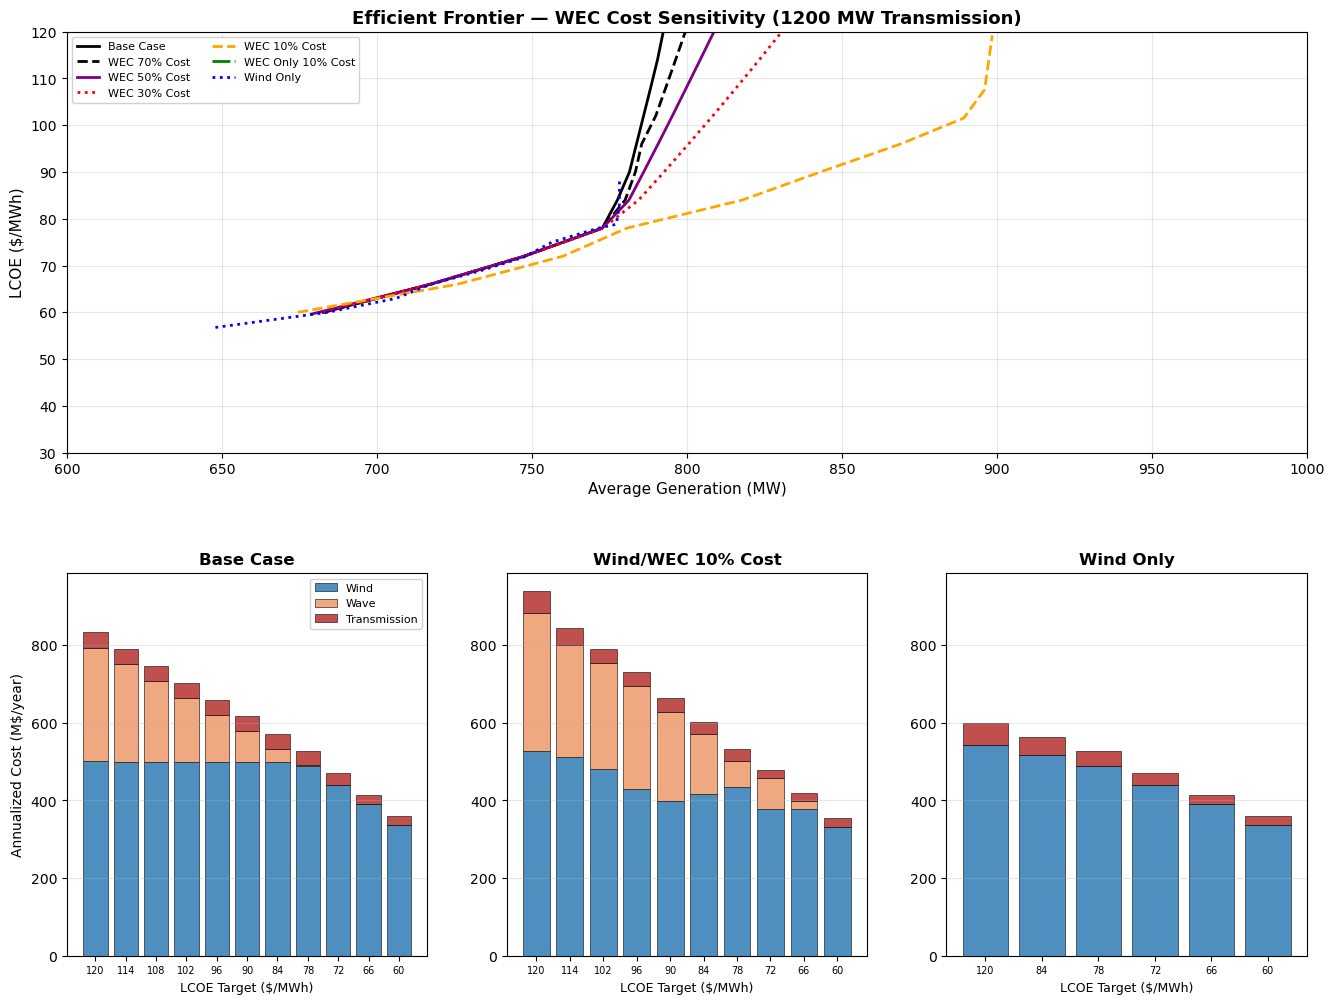

Done.


In [3]:
"""
Frontier_And_Costs_Figure.py
============================
Single composite figure, all plotted from data (vector quality):

    Top (full width):  Efficient frontier — LCOE vs average generation,
                       one line per cost-sensitivity scenario.
    Bottom (3 panels): Annualized system cost breakdown by technology
                       (Wind / Wave / Transmission) vs LCOE target, for
                       Base Case, Wind/WEC 10% Cost, and Wind Only.

Reads the Combined_AllLCOE.npz files (across-target results).

Notebook use: add %matplotlib inline at the top, then run this cell.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PORT = r"C:\Users\rmiller9\Documents\East Coast Model\Portfolios"

def combined(folder):
    return rf"{PORT}\{folder}\Combined_AllLCOE.npz"

# --- Efficient frontier: all sensitivity scenarios (path, label, color, linestyle) ---
FRONTIER_RUNS = [
    (combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW"),
     "Base Case", "black", "-"),
    (combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.7"),
     "WEC 70% Cost", "black", "--"),
    (combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.5"),
     "WEC 50% Cost", "purple", "-"),
    (combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.3"),
     "WEC 30% Cost", "red", ":"),
    (combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1"),
     "WEC 10% Cost", "orange", "--"),
    (combined(r"2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1"),
     "WEC Only 10% Cost", "green", "-."),
    (combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW"),
     "Wind Only", "blue", ":"),
]

# --- Cost breakdowns: three scenarios (title, path) ---
COST_PANELS = [
    ("Base Case",
     combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW")),
    ("Wind/WEC 10% Cost",
     combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_2009_2013_HalfScale_63.62_Transmission_1200MW_wave0.1")),
    ("Wind Only",
     combined(r"Upscale3h_0.1Degree_2009_2013_GenCost_ATB_18MW_2030_Transmission_1200MW_wave0.5")),
]

FRONTIER_XLIM = (600, 1000)
FRONTIER_YLIM = (30, 120)

WIND_C = "#4F8FBF"
WAVE_C = "#F0A881"
TRANS_C = "#C0504D"

SAVE_PATH = None  # e.g. r"C:\...\Frontier_And_Costs.png"

# ======================================================================
# FIGURE LAYOUT
# ======================================================================

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1.1, 1.0], hspace=0.30, wspace=0.22)

# --- Top: efficient frontier (spans all 3 columns) ---
ax_front = fig.add_subplot(gs[0, :])
for path, label, color, ls in FRONTIER_RUNS:
    try:
        Z = np.load(path, allow_pickle=True)
        mw   = np.asarray(Z["SaveTotalMWAvg"], dtype=float)
        lcoe = np.asarray(Z["Save_LCOE_Achieved"], dtype=float)
        Z.close()
    except Exception as e:
        print(f"Frontier: could not read {path}: {e}")
        continue
    mask = (~np.isnan(mw)) & (~np.isnan(lcoe))
    mw, lcoe = mw[mask], lcoe[mask]
    order = np.argsort(mw)
    ax_front.plot(mw[order], lcoe[order], label=label, color=color,
                  linestyle=ls, linewidth=2)

ax_front.set_xlim(*FRONTIER_XLIM)
ax_front.set_ylim(*FRONTIER_YLIM)
ax_front.set_xlabel("Average Generation (MW)", fontsize=11)
ax_front.set_ylabel("LCOE ($/MWh)", fontsize=11)
ax_front.set_title("Efficient Frontier — WEC Cost Sensitivity (1200 MW Transmission)",
                   fontsize=13, fontweight="bold")
ax_front.grid(True, alpha=0.3)
ax_front.legend(loc="upper left", ncol=2, fontsize=8, framealpha=0.9)

# --- Bottom: three stacked cost breakdowns ---
ymax = 0
cost_axes = []
for col, (title, path) in enumerate(COST_PANELS):
    ax = fig.add_subplot(gs[1, col])
    cost_axes.append(ax)
    try:
        Z = np.load(path, allow_pickle=True)
        targets = np.asarray(Z["Save_LCOETarget"], dtype=float)
        c_wind  = np.asarray(Z["Save_CostWind"], dtype=float)
        c_wave  = np.asarray(Z["Save_CostWave"], dtype=float)
        c_trans = np.asarray(Z["Save_CostTransmission"], dtype=float)
        Z.close()
    except Exception as e:
        print(f"Cost panel: could not read {path}: {e}")
        continue

# Trim everything to a common length (some targets may not have solved)
    n = min(len(targets), len(c_wind), len(c_wave), len(c_trans))
    targets, c_wind, c_wave, c_trans = targets[:n], c_wind[:n], c_wave[:n], c_trans[:n]

    x = np.arange(n)
    ax.bar(x, c_wind, color=WIND_C, edgecolor="black", linewidth=0.4, label="Wind")
    ax.bar(x, c_wave, bottom=c_wind, color=WAVE_C, edgecolor="black", linewidth=0.4, label="Wave")
    ax.bar(x, c_trans, bottom=c_wind + c_wave, color=TRANS_C, edgecolor="black", linewidth=0.4, label="Transmission")

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.0f}" for t in targets], rotation=0, fontsize=7)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("LCOE Target ($/MWh)", fontsize=9)
    if col == 0:
        ax.set_ylabel("Annualized Cost (M$/year)", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ymax = max(ymax, np.nanmax(c_wind + c_wave + c_trans))

# Shared y-limit so the three panels are directly comparable
for ax in cost_axes:
    ax.set_ylim(0, ymax * 1.05)

# One shared legend for the cost panels
if cost_axes:
    h, l = cost_axes[0].get_legend_handles_labels()
    cost_axes[0].legend(h, l, loc="upper right", fontsize=8, framealpha=0.9)

if SAVE_PATH:
    fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
    print(f"Saved -> {SAVE_PATH}")

plt.show()
print("Done.")

In [1]:
"""
Plot_Portfolio_Standalone_NC.py
===============================
Standalone deployment-map plotter for a single per-LCOE portfolio .npz file,
retargeted to the North Carolina offshore domain.

Draws coastline, state borders, bathymetry contours, and populated places
pulled from the Natural Earth ne_10m_populated_places shapefile (instead of a
hardcoded city list).

The per-LCOE .npz files store decision variables (Y_Wind, Y_Wave, Y_Kite,
s_Transmission) but NOT the site lat/longs. Those are reloaded from the
original tech-design .npz files specified in the CONFIGURATION block.

Usage:
    1. Set the paths in the CONFIGURATION block.
    2. Run:  python Plot_Portfolio_Standalone_NC.py
       — or paste into a Jupyter notebook (add %matplotlib inline at top).
"""

import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xarray as xr
from matplotlib.lines import Line2D
import math

# ======================================================================
# CONFIGURATION — edit these paths for your machine / run
# ======================================================================

# Portfolio per-LCOE shard to plot (North Carolina run)
PORTFOLIO_NPZ = r"C:\Users\rmiller9\Documents\C:\Users\rmiller9\Documents\GUI Project\portfolioOptModelApp\backend\Portfolios\GenPU_ATB_18MW_2030_Maryland_Maryland_HalfScale_63.62_KitePower_Design1_Maryland_100m_Transmission_1200MW_Maryland.npz"

# --- Original tech-design files (same ones passed to the optimizer) ---
# These contain the LatLong arrays that correspond to Y_Wind, Y_Wave, Y_Kite.
# Leave a list EMPTY if that technology was not used in the run.

PathWindDesigns = [
    r"C:\Users\rmiller9\Documents\GUI Project\portfolioOptModelApp\backend\Tech Outputs\Wind\GenPU_ATB_18MW_2030_Maryland.npz",
]

PathWaveDesigns = [
    r"C:\Users\rmiller9\Documents\GUI Project\portfolioOptModelApp\backend\Tech Outputs\Wave\ByState\Maryland_HalfScale_63.62.npz",
]

# Wind + wave only by default. Add a path here if a kite design was used.
PathKiteDesigns = [r"C:\Users\rmiller9\Documents\GUI Project\portfolioOptModelApp\backend\Tech Outputs\Current\KitePower_Design1_Maryland_100m.npz"
]

PathTransmissionDesign = r"C:\Users\rmiller9\Documents\GUI Project\portfolioOptModelApp\backend\Tech Outputs\Transmission\ByState\Transmission_1200MW_Maryland.npz"

# --- Geospatial overlays ---
DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
PLACES_SHP  = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_populated_places.shp"

# Collection radius in km
MAX_COLLECTION_RADIUS_KM = 30.0

# City filter (Natural Earth populated places)
CITY_STATE   = "North Carolina"   # match against ADM1NAME; set None to skip the state filter
CITY_POP_MIN = 100_000            # minimum POP_MAX to label; set None to skip

# Domain bounds (degrees). Set USE_AUTO_FIT = True to frame to deployed sites instead.
USE_AUTO_FIT = False
XLIM = (-79.5, -74.5)
YLIM = (33.0, 37.5)
PAD  = 2.0  # padding (deg) used only when USE_AUTO_FIT is True

# Output — set to a folder path to save a PNG, or None to just display
SAVE_DIR  = None        # e.g. r"C:\Users\rmiller9\Documents\East Coast Model\Plots"
SAVE_NAME = "Plot_DeploymentMap_NC.png"

# ======================================================================
# STYLE
# ======================================================================

TECH_COLORS = {
    "Wind":    "dodgerblue",
    "Kite":    "limegreen",
    "Wave":    "darkorange",
    "Coaxial": "mediumorchid",
    "Tidal":   "crimson",
}

DEPTH_LEVELS = [30, 100, 500, 1000, 2000]
DEPTH_COLORS = {
    30:   "purple",
    100:  "royalblue",
    500:  "teal",
    1000: "darkorange",
    2000: "gold",
}

# ======================================================================
# HELPERS
# ======================================================================

def km_to_deg_lon(km, lat_deg):
    return km / (111.32 * np.cos(np.radians(lat_deg)))

def km_to_deg_lat(km):
    return km / 110.574


def _load_latlong_concat(design_paths):
    """Load and concatenate LatLong arrays from a list of tech-design .npz files."""
    all_ll = []
    for p in design_paths:
        D = np.load(p, allow_pickle=True)
        all_ll.append(D["LatLong"])
        D.close()
    if len(all_ll) == 0:
        return np.empty((0, 2))
    return np.concatenate(all_ll, axis=0)

# ======================================================================
# LOAD GEO DATA
# ======================================================================

print("Loading geospatial overlays …")

ds      = xr.open_dataset(DEPTH_NC)
lat_d   = ds["lat"].values[::2]
lon_d   = ds["lon"].values[::2]
depth   = ds["depth"].values[::2, ::2]
LonGrid, LatGrid = np.meshgrid(lon_d, lat_d)
ds.close()

coast   = gpd.read_file(COAST_SHP)
borders = gpd.read_file(BORDERS_SHP)
places  = gpd.read_file(PLACES_SHP)

coast   = coast.set_crs(epsg=4326)   if coast.crs is None   else coast.to_crs(epsg=4326)
borders = borders.set_crs(epsg=4326) if borders.crs is None else borders.to_crs(epsg=4326)
places  = places.set_crs(epsg=4326)  if places.crs is None  else places.to_crs(epsg=4326)

# ======================================================================
# LOAD SITE LAT/LONGS FROM TECH DESIGN FILES
# ======================================================================

print("Loading site coordinates from tech-design files …")
WindLatLong = _load_latlong_concat(PathWindDesigns)
WaveLatLong = _load_latlong_concat(PathWaveDesigns)
KiteLatLong = _load_latlong_concat(PathKiteDesigns)

TData        = np.load(PathTransmissionDesign, allow_pickle=True)["TransmissionLineParameters"].item()
TransLatLong = TData["TL_LatLong"]
print(f"  Wind sites:  {len(WindLatLong)}")
print(f"  Wave sites:  {len(WaveLatLong)}")
print(f"  Kite sites:  {len(KiteLatLong)}")
print(f"  Trans hubs:  {len(TransLatLong)}")

# ======================================================================
# LOAD PORTFOLIO DECISION VARIABLES
# ======================================================================

print(f"Loading portfolio: {PORTFOLIO_NPZ}")
Z = np.load(PORTFOLIO_NPZ, allow_pickle=True)

lcoe_target   = float(Z["LCOE_Target"])
lcoe_achieved = float(Z["LCOE_Achieved"])

Y_Wind = Z["Y_Wind"]          # (num_wind_sites,) — units deployed per site
Y_Wave = Z["Y_Wave"]          # (num_wave_sites,)
Y_Kite = Z["Y_Kite"] if "Y_Kite" in Z.files else np.empty((0,))
s_arr  = Z["s_Transmission"]  # (num_trans_hubs,) — binary, one selected
Z.close()

# Sanity checks
assert len(Y_Wind) == len(WindLatLong), \
    f"Y_Wind length ({len(Y_Wind)}) != WindLatLong length ({len(WindLatLong)}). Check design paths."
assert len(Y_Wave) == len(WaveLatLong), \
    f"Y_Wave length ({len(Y_Wave)}) != WaveLatLong length ({len(WaveLatLong)}). Check design paths."
assert len(Y_Kite) == len(KiteLatLong), \
    f"Y_Kite length ({len(Y_Kite)}) != KiteLatLong length ({len(KiteLatLong)}). Check design paths."
assert len(s_arr) == len(TransLatLong), \
    f"s_Transmission length ({len(s_arr)}) != TransLatLong length ({len(TransLatLong)}). Check transmission path."

print("All dimension checks passed.")

# ======================================================================
# PLOT
# ======================================================================

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor("#d9d9d9")  # grey land background

# Fill ocean areas with blue using the bathymetry grid.
ax.contourf(LonGrid, LatGrid, depth,
            levels=[0, depth.max()], colors=["aliceblue"], zorder=1)

legend_handles = []
all_lons = []
all_lats = []
total_units = 0

# --- Deployed sites per technology ---
tech_data = [
    ("Wind", Y_Wind, WindLatLong),
    ("Wave", Y_Wave, WaveLatLong),
    ("Kite", Y_Kite, KiteLatLong),
]

for tech_name, Y_arr, LatLong in tech_data:
    if len(Y_arr) == 0:
        continue
    active = np.where(Y_arr > 0.5)[0]
    if len(active) == 0:
        continue

    ll    = LatLong[active]
    units = Y_arr[active]
    color = TECH_COLORS.get(tech_name, "gray")
    sizes = np.clip(15 + units * 8, 15, 150)

    ax.scatter(ll[:, 1], ll[:, 0], s=sizes, c=color,
               edgecolors="black", linewidths=0.3, alpha=0.85, zorder=4)

    n_sites = len(units)
    n_units = int(units.sum())
    total_units += n_units

    if tech_name == "Wave":
        n_arrays = math.ceil(n_units / 100)
        label = f"{tech_name}: {n_sites} sites, {n_arrays} arrays"
    else:
        label = f"{tech_name}: {n_sites} sites, {n_units} units"

    legend_handles.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
               markeredgecolor="black", markersize=8,
               label=label)
    )

    all_lons.extend(ll[:, 1].tolist())
    all_lats.extend(ll[:, 0].tolist())

# --- Transmission hub ---
hub_idx = np.argmax(s_arr)
hub_ll  = TransLatLong[hub_idx]

ax.scatter(hub_ll[1], hub_ll[0], s=250, c="red", marker="*",
           edgecolors="black", linewidths=0.8, zorder=6)
legend_handles.append(
    Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
           markeredgecolor="black", markersize=14, label="Transmission Hub")
)
all_lons.append(hub_ll[1])
all_lats.append(hub_ll[0])

# --- Collection radius circle ---
r_lat = km_to_deg_lat(MAX_COLLECTION_RADIUS_KM)
r_lon = km_to_deg_lon(MAX_COLLECTION_RADIUS_KM, hub_ll[0])
circle = mpatches.Ellipse(
    (hub_ll[1], hub_ll[0]), width=2 * r_lon, height=2 * r_lat,
    fill=False, edgecolor="red", linewidth=1.5, linestyle="--", zorder=5,
)
ax.add_patch(circle)
legend_handles.append(
    Line2D([0], [0], color="red", linestyle="--", lw=1.5,
           label=f"Collection radius ({MAX_COLLECTION_RADIUS_KM:.0f} km)")
)

# --- Domain bounds ---
if USE_AUTO_FIT and all_lons:
    xlim = (min(all_lons) - PAD, max(all_lons) + PAD)
    ylim = (min(all_lats) - PAD, max(all_lats) + PAD)
else:
    xlim = XLIM
    ylim = YLIM

# --- Geospatial overlays (depth contours + coastline + borders) ---
for lvl in DEPTH_LEVELS:
    cs = ax.contour(LonGrid, LatGrid, depth,
                    levels=[lvl], colors=[DEPTH_COLORS[lvl]],
                    linewidths=1.0, zorder=3)
    ax.clabel(cs, inline=True, fontsize=7, fmt={lvl: f"{lvl} m"})

coast.plot(ax=ax, linewidth=1.2, color="black", zorder=5, antialiased=False)
borders.plot(ax=ax, linewidth=0.6, color="black", zorder=5, antialiased=False)

# --- Populated places from Natural Earth ---
sub = places.copy()
if CITY_STATE is not None and "ADM1NAME" in sub.columns:
    sub = sub[sub["ADM1NAME"] == CITY_STATE]
if CITY_POP_MIN is not None and "POP_MAX" in sub.columns:
    sub = sub[sub["POP_MAX"] >= CITY_POP_MIN]

for _, row in sub.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y
    if xlim[0] <= lon <= xlim[1] and ylim[0] <= lat <= ylim[1]:
        name = row.get("NAME", "")
        ax.plot(lon, lat, "s", color="black", markersize=4, zorder=7)
        ax.annotate(name, (lon, lat), fontsize=7, fontweight="bold",
                    xytext=(4, 4), textcoords="offset points", zorder=7,
                    color="black",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# --- Legends ---
depth_handles = [
    Line2D([0], [0], color=DEPTH_COLORS[l], lw=2, label=f"{l} m")
    for l in DEPTH_LEVELS
]

leg1 = ax.legend(handles=legend_handles, loc="upper left",
                 frameon=True, framealpha=0.9, facecolor="white",
                 title="Deployments")
ax.add_artist(leg1)

ax.legend(handles=depth_handles, loc="lower right",
          frameon=True, framealpha=0.9, facecolor="white",
          title="Bathymetry")

ax.set_title(
    f"Portfolio Deployment (North Carolina) — LCOE Target: {lcoe_target:.0f} $/MWh"
    f"  |  Achieved: {lcoe_achieved:.1f} $/MWh"
    f"  |  {total_units} total units",
    fontsize=11,
)

plt.tight_layout()

# --- Save / show ---
if SAVE_DIR:
    out = os.path.join(SAVE_DIR, SAVE_NAME)
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved → {out}")

plt.show()
print("Done.")

Loading geospatial overlays …
Loading site coordinates from tech-design files …


ModuleNotFoundError: No module named 'numpy._core'